# 2D Sound Baseline v0.8

Category: `training`

Purpose:
Test whether the current validated 2-channel 2D representation (`normalized_window` + `active_mask`) produces useful signal on a controlled pump subset while emitting a self-describing training run record.

Inputs:
- tracked export manifests from `preprocessing/03.training-export/output/manifests/`
- local tensor exports under `training-data/`
- fixed baseline architecture `Baseline2DCNN`

Outputs:
- canonical run artifacts in `models/<run_id>/`
- `run_manifest.json`
- `training_history.json`
- `metrics.json`
- `split_membership.csv`
- `model_card.md`
- optional local-only checkpoints (`.pt`), intentionally excluded from Git

Decision supported:
- `READY_FOR_NEXT_DECISION` if the pipeline, metadata capture, and training run complete cleanly
- `PATCH_REQUIRED` otherwise


## 1. Imports and repo-root detection


In [25]:
from pathlib import Path
from typing import Sequence
from datetime import datetime, timezone
import hashlib
import json
import platform
import random
import re
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

try:
    import torchaudio
except Exception:
    torchaudio = None

try:
    import pyarrow
except Exception:
    pyarrow = None

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    from sklearn.metrics import classification_report, roc_auc_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'train').exists() and (candidate / 'preprocessing').exists():
            return candidate
    raise RuntimeError('Could not locate repo root containing train/ and preprocessing/.')


REPO_ROOT = find_repo_root(Path.cwd())
print(f'Using repo root: {REPO_ROOT}')


def repo_rel(path_value) -> str:
    path = Path(path_value).expanduser().resolve()
    try:
        return path.relative_to(REPO_ROOT).as_posix()
    except Exception:
        return str(path)


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path_value) -> str | None:
    path = Path(path_value)
    if not path.exists() or not path.is_file():
        return None
    digest = hashlib.sha256()
    with path.open('rb') as fh:
        for chunk in iter(lambda: fh.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


Using repo root: /home/mitch/development/raccoon-ball


## 2. Configuration


In [26]:
NOTEBOOK_RELATIVE_PATH = Path('train/2d-cnn/notebooks/2d_sound_v0.8.ipynb')
NOTEBOOK_PATH = REPO_ROOT / NOTEBOOK_RELATIVE_PATH

MANIFEST_ROOT = REPO_ROOT / 'preprocessing' / '03.training-export' / 'output' / 'manifests'
training_data_root = REPO_ROOT / 'training-data'
models_root = REPO_ROOT / 'models'

machine_filter = 'pump'


# Split strategy:
# - 'clip_random': random clip split per class (previous behavior).
# - 'unit_holdout': keep entire unit ids out of train for stricter validation.
# split_strategy = 'unit_holdout'  # {'clip_random', 'unit_holdout'}
split_strategy = 'unit_holdout'  # {'clip_random', 'unit_holdout'}

# Unit-id parsing patterns used by unit_holdout strategy.
unit_id_regex_by_machine = {
    'pump': r'pump-(\d{2})-',
    'fan': r'fan-(\d{2})-',
    'slider': r'slider-(\d{2})-',
    'valve': r'valve-(\d{2})-',
}
unit_id_fallback_regex = r'-(\d{2})-(?:nm|ab)-'

# Unit holdout controls.
# - If unit_holdout_ids is provided, those units are validation holdouts.
# - Otherwise, auto-select holdout units from available units in selected clips.
unit_holdout_ids = None  # Example: ['06']
auto_select_holdout_units = True
num_holdout_units = 1
require_balanced_unit_holdout = True  # require both classes in train and validation for holdout units.

# Data input mode:
# - 'clip_npz': original flow with clip/file and window manifests from exporter.
# - 'shard_npz': window manifests produced by utilities/pack_npz_shards_by_machine_type_v0.1.ipynb.
# manifest_mode = 'shard_npz'  # {'clip_npz', 'shard_npz'}
manifest_mode = 'shard_npz'  # {'clip_npz', 'shard_npz'}

if manifest_mode == 'clip_npz':
    window_manifest_paths = [
        MANIFEST_ROOT / '20260319_152022_windows.parquet',
        MANIFEST_ROOT / '20260319_155015_windows.parquet',
    ]
    clip_manifest_paths = [
        MANIFEST_ROOT / '20260319_152022_files.parquet',
        MANIFEST_ROOT / '20260319_155015_files.parquet',
    ]
    preprocessing_config_paths = [
        MANIFEST_ROOT / '20260319_152022_config.json',
        MANIFEST_ROOT / '20260319_155015_config.json',
    ]
elif manifest_mode == 'shard_npz':
    shard_runs_root = training_data_root / str(machine_filter).strip().lower() / 'shards'
    shard_window_manifest_candidates = sorted(shard_runs_root.glob('*/manifests/shard_windows.parquet'))
    if not shard_window_manifest_candidates:
        raise FileNotFoundError(
            'No shard window manifests found for shard_npz mode. '            f'Expected files like training-data/{machine_filter}/shards/<run_id>/manifests/shard_windows.parquet. '            'Run utilities/pack_npz_shards_by_machine_type_v0.1.ipynb first, or switch manifest_mode to clip_npz.'
        )

    SHARD_WINDOW_MANIFEST_PATH = shard_window_manifest_candidates[-1]
    SHARD_MANIFEST_ROOT = SHARD_WINDOW_MANIFEST_PATH.parent

    window_manifest_paths = [SHARD_WINDOW_MANIFEST_PATH]
    clip_manifest_paths = []  # clip rows are derived from window manifests in shard mode.
    preprocessing_config_paths = []
else:
    raise ValueError(f'Unsupported manifest_mode={manifest_mode!r}. Use clip_npz or shard_npz.')

max_normal_clips = 1200
max_abnormal_clips = 1200
match_normal_to_abnormal_when_abnormal_limited = True
val_fraction = 0.2

batch_size = 32
num_epochs = 4
learning_rate = 5e-4
requested_device = 'cuda' if torch.cuda.is_available() else 'cpu'

random_seed = 42
deterministic_training = True

input_mode = 'normalized_plus_mask'
save_local_checkpoints = True

clip_aggregation_method = 'probability_mean'
if clip_aggregation_method not in {'probability_mean', 'majority_vote'}:
    raise ValueError(
        f'Unsupported clip_aggregation_method={clip_aggregation_method}. '
        "Use 'probability_mean' or 'majority_vote'."
    )

change_note = (
    'v0.7 RAM preload + optional shard manifest mode: keep clip-level split/eval contract, '
    'allow training directly from shard_windows manifests produced by utilities pack notebook.'
)

np.random.seed(random_seed)
random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)
if hasattr(torch.backends, 'cudnn'):
    torch.backends.cudnn.deterministic = bool(deterministic_training)
    torch.backends.cudnn.benchmark = not bool(deterministic_training)

if not NOTEBOOK_PATH.exists():
    raise FileNotFoundError(f'Notebook path does not exist: {NOTEBOOK_PATH}')

for required_path in [*window_manifest_paths, *clip_manifest_paths, *preprocessing_config_paths]:
    if not required_path.exists():
        raise FileNotFoundError(f'Required input path not found: {required_path}')

CHECKS = {
    'manifests loaded': False,
    'clip-level split applied': False,
    'split diagnostics printed': False,
    'dataset loader works': False,
    'training completed': False,
    'prediction distribution computed': False,
    'confusion matrix generated': False,
    'clip-level metrics computed': False,
    'history plots generated': False,
    'split membership saved': False,
    'metrics artifact saved': False,
    'clip-level artifacts saved': False,
    'run manifest saved': False,
    'model artifacts saved': False,
}

NAN_DETECTED = False
TRAINING_EXCEPTION = None

best_val_loss = float('inf')
best_epoch = None
best_state_dict = None
best_clip_acc = None
best_clip_auc = None
best_clip_metrics = None

MODEL_OUTPUT_DIR = None
FINAL_MODEL_PATH = None
BEST_MODEL_PATH = None
TRAINING_HISTORY_JSON_PATH = None
METRICS_JSON_PATH = None
RUN_MANIFEST_JSON_PATH = None
SPLIT_MEMBERSHIP_PATH = None
CLIP_LEVEL_SUMMARY_CSV_PATH = None
CLIP_LEVEL_SUMMARY_JSON_PATH = None
MODEL_CARD_PATH = None

print('Configuration loaded.')
print(f'notebook={NOTEBOOK_RELATIVE_PATH.as_posix()}')
print(f'manifest_mode={manifest_mode}')
if manifest_mode == 'shard_npz':
    print(f'auto-selected shard manifest root={repo_rel(SHARD_MANIFEST_ROOT)}')
print(f'input_mode={input_mode}')
print(f'requested_device={requested_device}, batch_size={batch_size}, num_epochs={num_epochs}, lr={learning_rate}')
print(f'clip_aggregation_method={clip_aggregation_method}')
print(f'split_strategy={split_strategy}')
print('window manifests:')
for path in window_manifest_paths:
    print(' -', repo_rel(path))
if clip_manifest_paths:
    print('clip manifests:')
    for path in clip_manifest_paths:
        print(' -', repo_rel(path))
else:
    print('clip manifests: (none; will derive clip rows from window manifests)')


Configuration loaded.
notebook=train/2d-cnn/notebooks/2d_sound_v0.8.ipynb
manifest_mode=shard_npz
auto-selected shard manifest root=training-data/pump/shards/20260322_131954_pump_npz_shards_v0.1/manifests
input_mode=normalized_plus_mask
requested_device=cuda, batch_size=32, num_epochs=4, lr=0.0005
clip_aggregation_method=probability_mean
split_strategy=unit_holdout
window manifests:
 - training-data/pump/shards/20260322_131954_pump_npz_shards_v0.1/manifests/shard_windows.parquet
clip manifests: (none; will derive clip rows from window manifests)


## 3. Manifest loading and clip-level split


In [27]:
# 3. Manifest loading and clip-level split

def _to_path_list(value):
    if isinstance(value, (str, Path)):
        raw = [value]
    elif isinstance(value, Sequence):
        raw = list(value)
    else:
        raise TypeError(f'Expected Path/str or a sequence of paths, got {type(value)}')

    out = []
    for v in raw:
        p = Path(v).expanduser()
        if not p.is_absolute():
            p = (REPO_ROOT / p).resolve()
        else:
            p = p.resolve()
        out.append(p)
    return out


def _read_parquet_many(paths, kind_name):
    dfs = []
    for p in paths:
        if not p.exists():
            raise FileNotFoundError(f'{kind_name} manifest not found: {p}')
        try:
            df = pd.read_parquet(p)
        except Exception as exc:
            raise RuntimeError(
                f'Failed to read {kind_name} parquet at {p}. Ensure pyarrow/fastparquet is installed.'
            ) from exc
        df = df.copy()
        df['_manifest_path'] = repo_rel(p)
        dfs.append(df)

    if not dfs:
        raise RuntimeError(f'No {kind_name} manifests provided.')
    return pd.concat(dfs, ignore_index=True)


def _pick_first_column(df, candidates, required=True, purpose=''):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f'Could not find required column for {purpose}. Tried: {candidates}. Available: {list(df.columns)}'
        )
    return None


def _normalize_path_str(x):
    return str(x).replace('\\', '/')


def _looks_missing(value) -> bool:
    if value is None:
        return True
    text = str(value).strip()
    return text == '' or text.lower() == 'nan'


def _pathish_to_clip_id(value) -> str:
    text = _normalize_path_str(str(value)).strip()
    if text.lower().endswith('.npz'):
        text = str(Path(text).with_suffix('.wav')).replace('\\', '/')
    return text


def _infer_machine_hint_from_path(path_value) -> str | None:
    text = str(path_value).lower()
    for token in ['pump', 'fan', 'slider', 'valve']:
        if re.search(rf'(^|[-_/]){token}($|[-_/])', text) or token in text:
            return token
    return None


def _resolve_npz_path(path_value):
    p = Path(str(path_value)).expanduser()
    candidates = []

    machine_hints = []
    inferred_machine = _infer_machine_hint_from_path(path_value)
    if machine_filter:
        machine_hints.append(str(machine_filter).strip().lower())
    if inferred_machine is not None:
        machine_hints.append(inferred_machine)

    dedup_hints = []
    seen_hints = set()
    for hint in machine_hints:
        if hint and hint not in seen_hints:
            seen_hints.add(hint)
            dedup_hints.append(hint)

    if p.is_absolute():
        abs_p = p.resolve()
        candidates.append(abs_p)

        try:
            rel_from_training_data = abs_p.relative_to(training_data_root)
            for hint in dedup_hints:
                candidates.append((training_data_root / hint / rel_from_training_data).resolve())
        except ValueError:
            pass
    else:
        candidates.append((REPO_ROOT / p).resolve())
        candidates.append((training_data_root / p).resolve())
        candidates.append((training_data_root / 'tensors' / p).resolve())
        for hint in dedup_hints:
            candidates.append((training_data_root / hint / p).resolve())
            candidates.append((training_data_root / hint / 'tensors' / p).resolve())

    dedup_candidates = []
    seen = set()
    for c in candidates:
        key = str(c)
        if key not in seen:
            seen.add(key)
            dedup_candidates.append(c)

    for candidate in dedup_candidates:
        if candidate.exists():
            return candidate
    return dedup_candidates[0]


def _label_from_text(text):
    t = str(text).lower()
    if ('abnormal' in t) or ('-ab-' in t) or re.search(r'(^|[-_/])ab($|[-_/])', t):
        return 1
    if ('normal' in t) or ('-nm-' in t) or re.search(r'(^|[-_/])nm($|[-_/])', t):
        return 0
    return None


def _infer_label(row, explicit_label_col, text_cols):
    if explicit_label_col is not None:
        v = row.get(explicit_label_col)
        if pd.notna(v):
            token = str(v).strip().lower()
            if token in {'normal', 'nm', '0', 'false', 'non_anomalous', 'non-anomalous'}:
                return 0
            if token in {'abnormal', 'ab', '1', 'true', 'anomalous', 'anomaly'}:
                return 1

    for c in text_cols:
        if c in row and pd.notna(row[c]):
            parsed = _label_from_text(row[c])
            if parsed is not None:
                return parsed
    return None


def _infer_machine(row, explicit_machine_col, text_cols):
    if explicit_machine_col is not None:
        v = row.get(explicit_machine_col)
        if pd.notna(v):
            return str(v).strip().lower()

    text = ' '.join(str(row[c]) for c in text_cols if c in row and pd.notna(row[c])).lower()
    for token in ['pump', 'fan', 'slider', 'valve']:
        if re.search(rf'(^|[-_/]){token}($|[-_/])', text) or token in text:
            return token
    return None


def _infer_db_level(row, text_cols):
    text = ' '.join(str(row[c]) for c in text_cols if c in row and pd.notna(row[c])).lower()
    match = re.search(r'([+-]?\d+)db', text)
    if match:
        return int(match.group(1))
    match = re.search(r'([+-]\d+)-', text)
    if match:
        return int(match.group(1))
    return None


def _split_clip_ids(ids, val_fraction_local=0.2, seed=42):
    ids = list(dict.fromkeys([str(x) for x in ids]))
    if len(ids) == 0:
        return [], []

    rng = np.random.default_rng(seed)
    rng.shuffle(ids)

    if len(ids) < 2:
        return ids, []

    n_val = int(round(len(ids) * val_fraction_local))
    n_val = max(1, min(n_val, len(ids) - 1))
    val_ids = ids[:n_val]
    train_ids = ids[n_val:]
    return train_ids, val_ids


def _extract_unit_id_from_text(text_value, machine_hint: str | None = None):
    if _looks_missing(text_value):
        return None
    t = str(text_value).lower()

    pattern = unit_id_regex_by_machine.get(str(machine_hint).lower()) if machine_hint else None
    if pattern is not None:
        m = re.search(pattern, t)
        if m:
            return str(m.group(1))

    for pat in unit_id_regex_by_machine.values():
        m = re.search(pat, t)
        if m:
            return str(m.group(1))

    m = re.search(unit_id_fallback_regex, t)
    if m:
        return str(m.group(1))
    return None


def _select_holdout_units_for_validation(df: pd.DataFrame) -> list[str]:
    available_units = sorted([str(u) for u in df['unit_id'].dropna().astype(str).unique().tolist() if str(u).strip()])
    if not available_units:
        raise RuntimeError(
            'split_strategy=unit_holdout requires unit_id values, but none were inferred. '
            'Adjust unit_id_regex_by_machine or provide explicit unit_id in manifests.'
        )

    if unit_holdout_ids is not None:
        requested = [str(u).strip() for u in unit_holdout_ids if str(u).strip()]
        missing = sorted(set(requested) - set(available_units))
        if missing:
            raise RuntimeError(
                f'Configured unit_holdout_ids contain values not present in selected clips: {missing}. '
                f'Available units: {available_units}'
            )
        if not requested:
            raise RuntimeError('unit_holdout_ids is set but empty after normalization.')
        return sorted(requested)

    if not auto_select_holdout_units:
        raise RuntimeError(
            'split_strategy=unit_holdout requires either unit_holdout_ids or auto_select_holdout_units=True.'
        )

    unit_label_table = df.groupby(['unit_id', 'label']).size().unstack(fill_value=0)
    if require_balanced_unit_holdout:
        eligible = [
            str(u) for u, row in unit_label_table.iterrows()
            if int(row.get(0, 0)) > 0 and int(row.get(1, 0)) > 0
        ]
    else:
        eligible = [str(u) for u in unit_label_table.index.tolist()]

    if not eligible:
        raise RuntimeError(
            'No eligible units found for auto holdout under current constraints. '
            'Try disabling require_balanced_unit_holdout or adjusting selected clip limits.'
        )

    n = int(max(1, num_holdout_units))
    if n >= len(eligible):
        raise RuntimeError(
            f'num_holdout_units={n} is too large for eligible units={eligible}. '
            'At least one unit must remain for training.'
        )

    return sorted(eligible)[-n:]


def _validate_window_manifest_alignment(
    windows_subset_df: pd.DataFrame,
    subset_name: str = 'window subset',
    require_full_npz_coverage: bool = True,
):
    required_cols = {'npz_path', 'tensor_index'}
    missing = sorted(required_cols - set(windows_subset_df.columns))
    if missing:
        raise RuntimeError(f'{subset_name} is missing required columns for alignment check: {missing}')

    shape_mismatches = []
    count_mismatches = []
    index_mismatches = []

    for npz_path_value, group in windows_subset_df.groupby('npz_path', sort=False):
        npz_path = Path(str(npz_path_value))
        if not npz_path.exists():
            raise FileNotFoundError(f'NPZ referenced by {subset_name} does not exist: {npz_path}')

        with np.load(npz_path, allow_pickle=False) as npz:
            if 'normalized_window' not in npz.files or 'active_mask' not in npz.files:
                raise KeyError(
                    f'NPZ referenced by {subset_name} is missing required arrays: {npz_path}. '
                    "Expected keys: 'normalized_window' and 'active_mask'."
                )
            normalized = npz['normalized_window']
            active = npz['active_mask']

        if normalized.ndim != 3 or active.ndim != 3 or normalized.shape[1:] != (96, 64) or active.shape[1:] != (96, 64):
            shape_mismatches.append((str(npz_path), normalized.shape, active.shape))
            continue

        n_normalized = int(normalized.shape[0])
        n_mask = int(active.shape[0])
        if n_normalized != n_mask:
            count_mismatches.append((str(npz_path), int(len(group)), n_normalized, n_mask))
            continue

        tensor_indices = group['tensor_index'].astype(int).tolist()
        if not tensor_indices:
            continue

        min_idx = min(tensor_indices)
        max_idx = max(tensor_indices)
        if min_idx < 0 or max_idx >= n_normalized:
            index_mismatches.append((str(npz_path), min_idx, max_idx, n_normalized, len(tensor_indices)))
            continue

        if require_full_npz_coverage:
            manifest_count = int(len(group))
            if manifest_count != n_normalized:
                count_mismatches.append((str(npz_path), manifest_count, n_normalized, n_mask))
                continue

            sorted_idx = sorted(tensor_indices)
            expected = list(range(len(sorted_idx)))
            if sorted_idx != expected:
                index_mismatches.append((str(npz_path), sorted_idx[:5], sorted_idx[-5:], n_normalized, len(sorted_idx)))
        else:
            if len(set(tensor_indices)) != len(tensor_indices):
                index_mismatches.append((str(npz_path), 'duplicate_tensor_index', len(tensor_indices), len(set(tensor_indices)), n_normalized))

    if shape_mismatches:
        preview = '; '.join(
            [f'{p} normalized={ns}, active={as_}' for p, ns, as_ in shape_mismatches[:5]]
        )
        raise RuntimeError(
            f'Window tensor shape alignment failed for {subset_name}. First mismatches: {preview}'
        )

    if count_mismatches:
        preview = '; '.join(
            [f'{p} manifest_rows={m}, normalized_window={n}, active_mask={a}' for p, m, n, a in count_mismatches[:5]]
        )
        raise RuntimeError(
            f'Window row-count alignment failed for {subset_name}. First mismatches: {preview}'
        )

    if index_mismatches:
        preview = '; '.join([str(x) for x in index_mismatches[:5]])
        raise RuntimeError(
            f'Window tensor_index alignment failed for {subset_name}. First mismatches: {preview}'
        )

    return {
        'checked_npz_files': int(windows_subset_df['npz_path'].nunique()),
        'checked_window_rows': int(len(windows_subset_df)),
        'require_full_npz_coverage': bool(require_full_npz_coverage),
    }


def _derive_clip_id_from_row(row, relative_source_col=None, source_file_col=None, original_npz_col=None, fallback_npz_col='npz_path'):
    candidates = []
    if relative_source_col is not None:
        candidates.append(row.get(relative_source_col))
    if source_file_col is not None:
        candidates.append(row.get(source_file_col))
    if original_npz_col is not None:
        candidates.append(row.get(original_npz_col))
    if fallback_npz_col is not None:
        candidates.append(row.get(fallback_npz_col))

    for value in candidates:
        if not _looks_missing(value):
            clip_id = _pathish_to_clip_id(value)
            if clip_id:
                return clip_id
    return ''


window_df = _read_parquet_many(_to_path_list(window_manifest_paths), 'window')

if manifest_mode == 'clip_npz':
    clip_df = _read_parquet_many(_to_path_list(clip_manifest_paths), 'clip')
    if 'status' in clip_df.columns:
        clip_df = clip_df[clip_df['status'].isin(['exported', 'skipped_existing'])].copy()
else:
    clip_df = pd.DataFrame()

if window_df.empty:
    raise RuntimeError('Window manifest is empty after loading/filtering.')
if manifest_mode == 'clip_npz' and clip_df.empty:
    raise RuntimeError('Clip manifest is empty after loading/filtering.')

window_npz_col = _pick_first_column(
    window_df,
    ['shard_path', 'tensor_npz_path', 'npz_path', 'tensor_path', 'npz', 'path'],
    required=True,
    purpose='window npz path',
)
tensor_index_col = _pick_first_column(
    window_df,
    ['shard_tensor_index', 'tensor_index', 'window_index'],
    required=True,
    purpose='window tensor index',
)

window_df = window_df.copy()
window_df['npz_path'] = window_df[window_npz_col].map(lambda x: str(_resolve_npz_path(x)))
window_df['_npz_norm'] = window_df['npz_path'].map(_normalize_path_str)
window_df['tensor_index'] = window_df[tensor_index_col].astype(int)
window_df['window_manifest_path'] = window_df['_manifest_path']

window_relative_source_col = _pick_first_column(window_df, ['relative_source_path'], required=False, purpose='window relative source path')
window_source_file_col = _pick_first_column(window_df, ['source_file'], required=False, purpose='window source file')
window_original_npz_col = _pick_first_column(window_df, ['original_tensor_npz_path'], required=False, purpose='window original tensor npz path')

if window_relative_source_col is not None:
    window_df['relative_source_path'] = window_df[window_relative_source_col].astype(str)
elif window_source_file_col is not None:
    window_df['relative_source_path'] = window_df[window_source_file_col].astype(str)

if window_source_file_col is not None:
    window_df['source_file'] = window_df[window_source_file_col].astype(str)
elif 'relative_source_path' in window_df.columns:
    window_df['source_file'] = window_df['relative_source_path'].astype(str)

window_df['clip_id'] = window_df.apply(
    lambda r: _derive_clip_id_from_row(
        r,
        relative_source_col=window_relative_source_col,
        source_file_col=window_source_file_col,
        original_npz_col=window_original_npz_col,
        fallback_npz_col='npz_path',
    ),
    axis=1,
)
window_df['clip_id'] = window_df['clip_id'].map(_normalize_path_str).map(lambda x: str(x).strip())
if window_df['clip_id'].eq('').any():
    raise RuntimeError('Could not derive clip_id for one or more window rows. Please ensure source path columns are present.')

if manifest_mode == 'clip_npz':
    clip_npz_col = _pick_first_column(
        clip_df,
        ['tensor_npz_path', 'npz_path', 'tensor_path', 'npz', 'path'],
        required=True,
        purpose='clip npz path',
    )

    clip_df = clip_df.copy()
    clip_df['tensor_npz_path'] = clip_df[clip_npz_col].map(lambda x: str(_resolve_npz_path(x)))
    clip_df['_npz_norm'] = clip_df['tensor_npz_path'].map(_normalize_path_str)

    relative_source_col = _pick_first_column(clip_df, ['relative_source_path'], required=False, purpose='relative source path')
    source_file_col = _pick_first_column(clip_df, ['source_file'], required=False, purpose='source file')
    clip_id_col = _pick_first_column(
        clip_df,
        ['original_clip_id', 'source_clip_id', 'clip_id'],
        required=False,
        purpose='original clip id',
    )

    if relative_source_col is not None:
        clip_df['relative_source_path'] = clip_df[relative_source_col].astype(str)
    elif source_file_col is not None:
        clip_df['relative_source_path'] = clip_df[source_file_col].astype(str)
    else:
        clip_df['relative_source_path'] = clip_df['tensor_npz_path'].map(lambda x: Path(str(x)).with_suffix('.wav').as_posix())

    if source_file_col is not None:
        clip_df['source_file'] = clip_df[source_file_col].astype(str)
    else:
        clip_df['source_file'] = clip_df['relative_source_path']

    clip_df['clip_manifest_path'] = clip_df['_manifest_path']
    if clip_id_col is not None:
        clip_df['clip_id'] = clip_df[clip_id_col].astype(str)
        clip_id_source_field = clip_id_col
    elif relative_source_col is not None:
        clip_df['clip_id'] = clip_df['relative_source_path'].astype(str)
        clip_id_source_field = 'relative_source_path'
    elif source_file_col is not None:
        clip_df['clip_id'] = clip_df['source_file'].astype(str)
        clip_id_source_field = 'source_file'
    else:
        clip_df['clip_id'] = clip_df['tensor_npz_path'].map(lambda x: Path(str(x)).with_suffix('.wav').as_posix())
        clip_id_source_field = 'tensor_npz_path (fallback-derived)'

    clip_df['clip_id'] = clip_df['clip_id'].map(_normalize_path_str).map(lambda x: str(x).strip())

    clip_id_to_npz_count = clip_df.groupby('clip_id')['_npz_norm'].nunique()
    clip_id_collision = clip_id_to_npz_count[clip_id_to_npz_count > 1]
    if not clip_id_collision.empty:
        raise RuntimeError(
            'Clip id collision detected: one clip_id maps to multiple tensor_npz_path entries. '
            f'Examples: {clip_id_collision.head(10).to_dict()}'
        )

    npz_to_clip_id_count = clip_df.groupby('_npz_norm')['clip_id'].nunique()
    npz_collision = npz_to_clip_id_count[npz_to_clip_id_count > 1]
    if not npz_collision.empty:
        raise RuntimeError(
            'Manifest consistency error: one tensor_npz_path maps to multiple clip_id values. '
            f'Examples: {npz_collision.head(10).to_dict()}'
        )

    merge_key = '_npz_norm'
    clip_unique_key = '_npz_norm'
else:
    clip_id_source_field = 'derived from window manifest source fields'

    window_text_cols = [c for c in ['relative_source_path', 'source_file'] if c in window_df.columns]
    synth_cols = ['clip_id', '_npz_norm', 'npz_path', 'window_manifest_path', *window_text_cols]
    if window_original_npz_col is not None and window_original_npz_col in window_df.columns:
        synth_cols.append(window_original_npz_col)

    clip_df = window_df[synth_cols].copy().drop_duplicates('clip_id').reset_index(drop=True)

    if window_original_npz_col is not None and window_original_npz_col in clip_df.columns:
        clip_df['tensor_npz_path'] = clip_df[window_original_npz_col].map(lambda x: str(_resolve_npz_path(x)))
    else:
        clip_df['tensor_npz_path'] = clip_df['npz_path'].astype(str)

    clip_df['_npz_norm'] = clip_df['tensor_npz_path'].map(_normalize_path_str)
    if 'relative_source_path' not in clip_df.columns:
        clip_df['relative_source_path'] = clip_df['tensor_npz_path'].map(lambda x: Path(str(x)).with_suffix('.wav').as_posix())
    if 'source_file' not in clip_df.columns:
        clip_df['source_file'] = clip_df['relative_source_path']

    clip_df['clip_manifest_path'] = '(derived-from-window-manifest)'
    merge_key = 'clip_id'
    clip_unique_key = 'clip_id'

missing_clip_id_mask = clip_df['clip_id'].eq('') | clip_df['clip_id'].str.lower().eq('nan')
if missing_clip_id_mask.any():
    sample_cols = [c for c in ['tensor_npz_path', 'relative_source_path', 'source_file'] if c in clip_df.columns]
    examples = clip_df.loc[missing_clip_id_mask, sample_cols].head(5)
    raise RuntimeError('Clip id resolution failed: at least one clip has an empty clip_id. Example rows: ' + examples.to_string(index=False))

label_col = _pick_first_column(
    clip_df,
    ['label', 'class_label', 'class', 'target', 'condition', 'anomaly_label'],
    required=False,
    purpose='label',
)
machine_col = _pick_first_column(
    clip_df,
    ['machine', 'machine_type', 'machine_name'],
    required=False,
    purpose='machine',
)

text_cols_for_inference = [
    c for c in ['source_file', 'relative_source_path', 'tensor_npz_path'] if c in clip_df.columns
]
clip_df['label'] = clip_df.apply(lambda r: _infer_label(r, label_col, text_cols_for_inference), axis=1)
clip_df['machine'] = clip_df.apply(lambda r: _infer_machine(r, machine_col, text_cols_for_inference), axis=1)
clip_df['db_level'] = clip_df.apply(lambda r: _infer_db_level(r, text_cols_for_inference), axis=1)

unit_col = _pick_first_column(
    clip_df,
    ['unit_id', 'machine_unit_id', 'unit', 'machine_id'],
    required=False,
    purpose='unit id',
)

def _infer_unit_id(row):
    if unit_col is not None:
        raw = row.get(unit_col)
        if not _looks_missing(raw):
            return str(raw).strip()

    machine_hint = row.get('machine')
    for c in text_cols_for_inference:
        if c in row and pd.notna(row[c]):
            parsed = _extract_unit_id_from_text(row[c], machine_hint=machine_hint)
            if parsed is not None:
                return parsed
    return None

clip_df['unit_id'] = clip_df.apply(_infer_unit_id, axis=1)

missing_label_mask = clip_df['label'].isna()
if missing_label_mask.any():
    examples = clip_df.loc[missing_label_mask, text_cols_for_inference].head(5)
    msg = (
        'Could not infer normal/abnormal label for some clips. '
        'Please add a label column or use path naming containing normal/abnormal or -nm-/-ab-.'
    )
    raise RuntimeError(msg + ' Example rows: ' + examples.to_string(index=False))

clip_df['label'] = clip_df['label'].astype(int)
clip_df['condition'] = clip_df['label'].map({0: 'normal', 1: 'abnormal'})

if machine_filter:
    mf = str(machine_filter).strip().lower()
    clip_df = clip_df[clip_df['machine'].fillna('').str.contains(mf, regex=False)].copy()

normal_candidates = clip_df[clip_df['label'] == 0].drop_duplicates(clip_unique_key).sort_values('clip_id')
abnormal_candidates = clip_df[clip_df['label'] == 1].drop_duplicates(clip_unique_key).sort_values('clip_id')

selected_abnormal_df = abnormal_candidates.head(max_abnormal_clips).copy()
if selected_abnormal_df.empty:
    raise RuntimeError('No abnormal clips were selected. Check manifests/filtering.')

if match_normal_to_abnormal_when_abnormal_limited and len(selected_abnormal_df) < max_abnormal_clips:
    target_normal_count = min(max_normal_clips, len(selected_abnormal_df))
else:
    target_normal_count = max_normal_clips

selected_normal_df = normal_candidates.head(target_normal_count).copy()
if selected_normal_df.empty:
    raise RuntimeError('No normal clips were selected. Check manifests/filtering.')

selected_clips_df = pd.concat([selected_normal_df, selected_abnormal_df], ignore_index=True)

if merge_key == '_npz_norm':
    selected_lookup = selected_clips_df[
        ['_npz_norm', 'tensor_npz_path', 'clip_id', 'label', 'machine', 'unit_id', 'db_level', 'condition',
         'clip_manifest_path', 'relative_source_path', 'source_file']
    ].drop_duplicates('_npz_norm')
    selected_windows_df = window_df.merge(selected_lookup, on='_npz_norm', how='inner', suffixes=('_window', '_clip'))
else:
    selected_lookup = selected_clips_df[
        ['clip_id', 'label', 'machine', 'unit_id', 'db_level', 'condition',
         'clip_manifest_path', 'relative_source_path', 'source_file', 'tensor_npz_path']
    ].drop_duplicates('clip_id')
    selected_windows_df = window_df.merge(selected_lookup, on='clip_id', how='inner', suffixes=('_window', '_clip'))

# Canonicalize potentially suffixed columns after merge.
for base_col in [
    'clip_id',
    'label',
    'machine',
    'unit_id',
    'db_level',
    'condition',
    'clip_manifest_path',
    'relative_source_path',
    'source_file',
    'tensor_npz_path',
]:
    if base_col in selected_windows_df.columns:
        continue
    clip_col = f'{base_col}_clip'
    window_col = f'{base_col}_window'
    if clip_col in selected_windows_df.columns:
        selected_windows_df[base_col] = selected_windows_df[clip_col]
    elif window_col in selected_windows_df.columns:
        selected_windows_df[base_col] = selected_windows_df[window_col]

if 'clip_id_clip' in selected_windows_df.columns and 'clip_id_window' in selected_windows_df.columns:
    clip_mismatch = (
        selected_windows_df['clip_id_clip'].astype(str).map(_normalize_path_str).str.strip()
        != selected_windows_df['clip_id_window'].astype(str).map(_normalize_path_str).str.strip()
    )
    if clip_mismatch.any():
        examples = selected_windows_df.loc[clip_mismatch, ['clip_id_clip', 'clip_id_window']].head(10)
        raise RuntimeError(
            'Clip-id mismatch after window/clip merge. '
            f'Examples: {examples.to_dict(orient="records")}'
        )

required_selected_cols = {'clip_id', 'label', 'npz_path', 'tensor_index'}
missing_selected_cols = sorted(required_selected_cols - set(selected_windows_df.columns))
if missing_selected_cols:
    raise RuntimeError(
        'Selected windows are missing required columns after merge canonicalization: '
        f'{missing_selected_cols}. Available columns: {sorted(selected_windows_df.columns.tolist())}'
    )

selected_windows_df['clip_id'] = selected_windows_df['clip_id'].astype(str).map(_normalize_path_str).str.strip()

if selected_windows_df.empty:
    raise RuntimeError('Selected subset produced zero window rows. Check manifest alignment.')

alignment_stats = _validate_window_manifest_alignment(
    selected_windows_df,
    subset_name='selected windows',
    require_full_npz_coverage=(merge_key == '_npz_norm'),
)

per_clip_label_counts = selected_windows_df.groupby('clip_id')['label'].nunique(dropna=False)
if (per_clip_label_counts > 1).any():
    bad = per_clip_label_counts[per_clip_label_counts > 1].head(10)
    raise RuntimeError(
        'Clip label consistency failed: at least one clip_id has multiple labels. '
        f'Examples: {bad.to_dict()}'
    )

resolved_holdout_unit_ids = []
selected_unit_ids = sorted([str(u) for u in selected_clips_df['unit_id'].dropna().astype(str).unique().tolist()])

if split_strategy == 'clip_random':
    train_clip_ids = []
    val_clip_ids = []
    for label_value in [0, 1]:
        class_clip_ids = selected_clips_df.loc[selected_clips_df['label'] == label_value, 'clip_id'].astype(str).tolist()
        tr_ids, va_ids = _split_clip_ids(class_clip_ids, val_fraction_local=val_fraction, seed=random_seed + label_value)
        train_clip_ids.extend(tr_ids)
        val_clip_ids.extend(va_ids)
elif split_strategy == 'unit_holdout':
    resolved_holdout_unit_ids = _select_holdout_units_for_validation(selected_clips_df)

    val_clip_ids = selected_clips_df[
        selected_clips_df['unit_id'].astype(str).isin(set(resolved_holdout_unit_ids))
    ]['clip_id'].astype(str).tolist()
    train_clip_ids = selected_clips_df[
        ~selected_clips_df['unit_id'].astype(str).isin(set(resolved_holdout_unit_ids))
    ]['clip_id'].astype(str).tolist()
else:
    raise ValueError(f'Unsupported split_strategy={split_strategy!r}. Use clip_random or unit_holdout.')

if len(train_clip_ids) == 0 or len(val_clip_ids) == 0:
    raise RuntimeError(
        'Clip split produced an empty train or validation split. '
        'Increase selected clips or adjust split_strategy holdout configuration.'
    )

if set(train_clip_ids).intersection(set(val_clip_ids)):
    raise RuntimeError('Clip leakage detected: at least one clip appears in both train and validation.')

train_windows_df = selected_windows_df[selected_windows_df['clip_id'].astype(str).isin(train_clip_ids)].copy()
val_windows_df = selected_windows_df[selected_windows_df['clip_id'].astype(str).isin(val_clip_ids)].copy()

if train_windows_df.empty or val_windows_df.empty:
    raise RuntimeError('Train or validation window set is empty after clip-level split.')

train_clip_ids_set = set([str(x) for x in train_clip_ids])
val_clip_ids_set = set([str(x) for x in val_clip_ids])
train_unit_ids = sorted(selected_clips_df[selected_clips_df['clip_id'].astype(str).isin(train_clip_ids_set)]['unit_id'].dropna().astype(str).unique().tolist())
val_unit_ids = sorted(selected_clips_df[selected_clips_df['clip_id'].astype(str).isin(val_clip_ids_set)]['unit_id'].dropna().astype(str).unique().tolist())
unit_overlap = sorted(set(train_unit_ids).intersection(set(val_unit_ids)))

if split_strategy == 'unit_holdout' and unit_overlap:
    raise RuntimeError(
        'Unit leakage detected under unit_holdout strategy: some unit_ids appear in both train and validation. '
        f'Overlaps: {unit_overlap}'
    )

if require_balanced_unit_holdout:
    train_label_set = set(selected_clips_df[selected_clips_df['clip_id'].astype(str).isin(train_clip_ids_set)]['label'].astype(int).tolist())
    val_label_set = set(selected_clips_df[selected_clips_df['clip_id'].astype(str).isin(val_clip_ids_set)]['label'].astype(int).tolist())
    if not ({0, 1}.issubset(train_label_set) and {0, 1}.issubset(val_label_set)):
        raise RuntimeError(
            'Balanced holdout check failed: expected both labels present in train and validation. '
            f'train_labels={sorted(train_label_set)}, val_labels={sorted(val_label_set)}'
        )

split_membership_df = selected_clips_df[
    ['clip_id', 'label', 'machine', 'unit_id', 'db_level', 'condition', 'relative_source_path', 'source_file',
     'tensor_npz_path', 'clip_manifest_path']
].copy()
split_membership_df['split'] = split_membership_df['clip_id'].map(
    lambda clip_id: 'train' if str(clip_id) in set(train_clip_ids) else 'validation'
)
split_membership_df['label_name'] = split_membership_df['label'].map({0: 'normal', 1: 'abnormal'})
split_membership_df = split_membership_df[
    ['clip_id', 'split', 'label', 'label_name', 'machine', 'unit_id', 'db_level', 'condition',
     'relative_source_path', 'source_file', 'tensor_npz_path', 'clip_manifest_path']
].sort_values(['split', 'label', 'clip_id']).reset_index(drop=True)

CHECKS['manifests loaded'] = True
CHECKS['clip-level split applied'] = True

print(f'Loaded window rows: {len(window_df):,}')
print(f'Loaded clip rows: {len(clip_df):,}')
print(f'manifest_mode={manifest_mode}, merge_key={merge_key}')
print(f'Clip id source field: {clip_id_source_field}')
print(
    'Selected-window alignment check: '
    f"npz_files={alignment_stats['checked_npz_files']}, window_rows={alignment_stats['checked_window_rows']}, "
    f"full_coverage={alignment_stats['require_full_npz_coverage']}"
)
print(f'Selected normal clips: {len(selected_normal_df)}')
print(f'Selected abnormal clips: {len(selected_abnormal_df)}')
print(f'split_strategy={split_strategy}')
if split_strategy == 'unit_holdout':
    print(f'unit_holdout_ids(resolved)={resolved_holdout_unit_ids}')
print(f'selected_unit_ids={selected_unit_ids}')
print(f'train_unit_ids={train_unit_ids}')
print(f'val_unit_ids={val_unit_ids}')
print(f'Train clips: {len(train_clip_ids)} | Validation clips: {len(val_clip_ids)}')


Loaded window rows: 227,070
Loaded clip rows: 12,615
manifest_mode=shard_npz, merge_key=clip_id
Clip id source field: derived from window manifest source fields
Selected-window alignment check: npz_files=3, window_rows=43200, full_coverage=False
Selected normal clips: 1200
Selected abnormal clips: 1200
split_strategy=unit_holdout
unit_holdout_ids(resolved)=['02']
selected_unit_ids=['00', '02', '04', '06']
train_unit_ids=['00', '04', '06']
val_unit_ids=['02']
Train clips: 1873 | Validation clips: 527


## 4. Dataset loader and pre-training diagnostics


In [28]:
def _count_by_label(df, label_col='label'):
    vc = df[label_col].value_counts().sort_index()
    return int(vc.get(0, 0)), int(vc.get(1, 0))


class TwoChannelWindowDataset(Dataset):
    def __init__(
        self,
        rows_df: pd.DataFrame,
        input_mode_local: str = 'normalized_plus_mask',
        return_clip_id: bool = False,
        preload_to_ram: bool = True,
    ):
        required_cols = {'npz_path', 'tensor_index', 'label', 'clip_id'}
        missing = sorted(required_cols - set(rows_df.columns))
        if missing:
            raise ValueError(f'Dataset rows are missing required columns: {missing}')

        if input_mode_local not in {'normalized_plus_mask', 'normalized_only'}:
            raise ValueError(f'Unsupported input_mode: {input_mode_local}')

        self.rows = rows_df[['npz_path', 'tensor_index', 'label', 'clip_id']].reset_index(drop=True).copy()
        self.input_mode = input_mode_local
        self.return_clip_id = bool(return_clip_id)
        self.preload_to_ram = bool(preload_to_ram)

        self._x = None
        self._x_torch = None
        self._y_torch = None
        self._clip_ids = [str(v).strip() for v in self.rows['clip_id'].tolist()]
        self._preload_summary = {
            'enabled': self.preload_to_ram,
            'num_samples': int(len(self.rows)),
            'num_unique_npz': int(self.rows['npz_path'].nunique()),
            'bytes_x': 0,
            'bytes_y': 0,
            'bytes_total': 0,
        }

        if self.preload_to_ram:
            self._preload_all_windows()

    def _preload_all_windows(self):
        n = len(self.rows)
        if n == 0:
            raise RuntimeError('Dataset is empty after split/filtering; cannot preload.')

        x = np.empty((n, 2, 96, 64), dtype=np.float32)
        y = self.rows['label'].astype(np.int64).to_numpy(copy=True)

        npz_paths = self.rows['npz_path'].astype(str).to_numpy(copy=False)
        tensor_indices = self.rows['tensor_index'].astype(np.int64).to_numpy(copy=False)

        indices_by_path = {}
        for row_idx, npz_path in enumerate(npz_paths.tolist()):
            if npz_path not in indices_by_path:
                indices_by_path[npz_path] = []
            indices_by_path[npz_path].append(row_idx)

        for npz_path_str, row_indices_list in indices_by_path.items():
            npz_path = Path(npz_path_str)
            if not npz_path.exists():
                raise FileNotFoundError(f'NPZ missing during preload: {npz_path}')

            row_indices = np.asarray(row_indices_list, dtype=np.int64)
            local_tensor_indices = tensor_indices[row_indices]

            with np.load(npz_path, allow_pickle=False) as npz:
                if 'normalized_window' not in npz.files:
                    raise KeyError(f"Missing key 'normalized_window' in {npz_path}")
                if 'active_mask' not in npz.files:
                    raise KeyError(f"Missing key 'active_mask' in {npz_path}")

                normalized_all = npz['normalized_window']
                active_all = npz['active_mask']

                if normalized_all.ndim != 3 or active_all.ndim != 3:
                    raise ValueError(
                        f'Expected 3D arrays in {npz_path}; got normalized_window={normalized_all.shape}, active_mask={active_all.shape}'
                    )
                if normalized_all.shape[1:] != (96, 64):
                    raise ValueError(
                        f'normalized_window shape mismatch in {npz_path}: got {normalized_all.shape[1:]}, expected (96, 64)'
                    )
                if active_all.shape[1:] != (96, 64):
                    raise ValueError(
                        f'active_mask shape mismatch in {npz_path}: got {active_all.shape[1:]}, expected (96, 64)'
                    )

                if local_tensor_indices.size:
                    max_idx = int(local_tensor_indices.max())
                    min_idx = int(local_tensor_indices.min())
                    if min_idx < 0 or max_idx >= int(normalized_all.shape[0]):
                        raise IndexError(
                            f'tensor_index out of bounds for {npz_path}: min={min_idx}, max={max_idx}, N={int(normalized_all.shape[0])}'
                        )

                selected_normalized = normalized_all[local_tensor_indices].astype(np.float32, copy=False)
                x[row_indices, 0, :, :] = selected_normalized

                if self.input_mode == 'normalized_plus_mask':
                    selected_active = active_all[local_tensor_indices].astype(np.float32, copy=False)
                    x[row_indices, 1, :, :] = selected_active
                else:
                    x[row_indices, 1, :, :] = 0.0

        self._x = x
        self._x_torch = torch.from_numpy(self._x)
        self._y_torch = torch.from_numpy(y)
        self._preload_summary['bytes_x'] = int(self._x.nbytes)
        self._preload_summary['bytes_y'] = int(y.nbytes)
        self._preload_summary['bytes_total'] = int(self._x.nbytes + y.nbytes)

    def __len__(self):
        return len(self.rows)

    @property
    def preload_summary(self):
        return dict(self._preload_summary)

    def __getitem__(self, idx):
        if self.preload_to_ram:
            sample_x = self._x_torch[idx]
            sample_y = self._y_torch[idx]
            clip_id = self._clip_ids[idx]
            if self.return_clip_id:
                return sample_x, sample_y, clip_id
            return sample_x, sample_y

        row = self.rows.iloc[idx]
        npz_path = Path(str(row['npz_path']))
        tensor_index = int(row['tensor_index'])
        label = int(row['label'])
        clip_id = str(row['clip_id']).strip()

        if label not in (0, 1):
            raise ValueError(f'Invalid label at idx={idx}: {label}. Expected 0 (normal) or 1 (abnormal).')
        if not clip_id or clip_id.lower() == 'nan':
            raise ValueError(f'Missing clip_id at idx={idx}.')
        if not npz_path.exists():
            raise FileNotFoundError(f'NPZ not found at idx={idx}: {npz_path}')

        with np.load(npz_path, allow_pickle=False) as npz:
            if 'normalized_window' not in npz.files:
                raise KeyError(f"Missing key 'normalized_window' in {npz_path}")
            if 'active_mask' not in npz.files:
                raise KeyError(f"Missing key 'active_mask' in {npz_path}")

            normalized_all = npz['normalized_window']
            active_all = npz['active_mask']

            if tensor_index < 0 or tensor_index >= normalized_all.shape[0]:
                raise IndexError(
                    f'tensor_index out of bounds for {npz_path}: index={tensor_index}, N={normalized_all.shape[0]}'
                )

            normalized_window = normalized_all[tensor_index]
            active_mask = active_all[tensor_index]

        if normalized_window.shape != (96, 64):
            raise ValueError(
                f'normalized_window shape mismatch at idx={idx}: got {normalized_window.shape}, expected (96, 64)'
            )
        if active_mask.shape != (96, 64):
            raise ValueError(
                f'active_mask shape mismatch at idx={idx}: got {active_mask.shape}, expected (96, 64)'
            )

        channel_0 = normalized_window.astype(np.float32, copy=False)
        if self.input_mode == 'normalized_plus_mask':
            channel_1 = active_mask.astype(np.float32, copy=False)
        else:
            channel_1 = np.zeros_like(channel_0, dtype=np.float32)

        x = np.stack([channel_0, channel_1], axis=0)

        if x.shape != (2, 96, 64):
            raise ValueError(f'stacked tensor shape mismatch at idx={idx}: got {x.shape}, expected (2, 96, 64)')
        if x.dtype != np.float32:
            raise TypeError(f'stacked tensor dtype mismatch at idx={idx}: got {x.dtype}, expected float32')

        sample_x = torch.from_numpy(x)
        sample_y = torch.tensor(label, dtype=torch.long)
        if self.return_clip_id:
            return sample_x, sample_y, clip_id
        return sample_x, sample_y


def _format_gib(num_bytes: int) -> str:
    return f'{num_bytes / (1024 ** 3):.3f} GiB'


preload_windows_to_ram = True

train_dataset = TwoChannelWindowDataset(
    train_windows_df,
    input_mode_local=input_mode,
    return_clip_id=False,
    preload_to_ram=preload_windows_to_ram,
)
val_dataset = TwoChannelWindowDataset(
    val_windows_df,
    input_mode_local=input_mode,
    return_clip_id=True,
    preload_to_ram=preload_windows_to_ram,
)

train_generator = torch.Generator()
train_generator.manual_seed(random_seed)

pin_memory = (requested_device == 'cuda') and torch.cuda.is_available()
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
    generator=train_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

sample_x, sample_y = train_dataset[0]
batch_x, batch_y = next(iter(train_loader))
val_sample_x, val_sample_y, val_sample_clip_id = val_dataset[0]

train_clip_df = selected_clips_df[selected_clips_df['clip_id'].astype(str).isin(train_clip_ids)].copy()
val_clip_df = selected_clips_df[selected_clips_df['clip_id'].astype(str).isin(val_clip_ids)].copy()

train_normal_clips, train_abnormal_clips = _count_by_label(train_clip_df, label_col='label')
val_normal_clips, val_abnormal_clips = _count_by_label(val_clip_df, label_col='label')
train_normal_windows, train_abnormal_windows = _count_by_label(train_windows_df, label_col='label')
val_normal_windows, val_abnormal_windows = _count_by_label(val_windows_df, label_col='label')

def _balance_text(df):
    vc = df['label'].value_counts().sort_index()
    total = int(vc.sum()) if len(vc) else 0
    n0 = int(vc.get(0, 0))
    n1 = int(vc.get(1, 0))
    if total == 0:
        return 'normal=0 (0.00%), abnormal=0 (0.00%)'
    return f'normal={n0} ({100.0*n0/total:.2f}%), abnormal={n1} ({100.0*n1/total:.2f}%)'


print('1. split summary:')
print(f'   selected clips={len(selected_clips_df):,}, train clips={len(train_clip_ids):,}, validation clips={len(val_clip_ids):,}')
print('2. clip balance:')
print(f'   train clips: normal={train_normal_clips}, abnormal={train_abnormal_clips}')
print(f'   validation clips: normal={val_normal_clips}, abnormal={val_abnormal_clips}')
print('3. window balance:')
print('   train:', _balance_text(train_windows_df))
print('   validation:', _balance_text(val_windows_df))
print('4. RAM preload summary:')
print(
    f"   train: samples={train_dataset.preload_summary['num_samples']:,}, unique_npz={train_dataset.preload_summary['num_unique_npz']:,}, "
    f"bytes={_format_gib(train_dataset.preload_summary['bytes_total'])}"
)
print(
    f"   val: samples={val_dataset.preload_summary['num_samples']:,}, unique_npz={val_dataset.preload_summary['num_unique_npz']:,}, "
    f"bytes={_format_gib(val_dataset.preload_summary['bytes_total'])}"
)
print('5. one sample / batch checks:')
print('   single sample shape:', tuple(sample_x.shape))
print('   single sample dtype:', sample_x.dtype)
print('   single sample label:', int(sample_y))
print('   batch shape:', tuple(batch_x.shape))
print('   batch dtype:', batch_x.dtype)
print('   batch device:', batch_x.device)
print('   unique labels in one batch:', torch.unique(batch_y).tolist())
print('   validation sample clip_id:', val_sample_clip_id)
print('   validation sample label:', int(val_sample_y))

if not isinstance(val_sample_clip_id, str) or not val_sample_clip_id.strip():
    raise RuntimeError('Validation sample did not return a valid clip_id.')


display(split_membership_df.head(10))

CHECKS['dataset loader works'] = True
CHECKS['split diagnostics printed'] = True


1. split summary:
   selected clips=2,400, train clips=1,873, validation clips=527
2. clip balance:
   train clips: normal=1006, abnormal=867
   validation clips: normal=194, abnormal=333
3. window balance:
   train: normal=18108 (53.71%), abnormal=15606 (46.29%)
   validation: normal=3492 (36.81%), abnormal=5994 (63.19%)
4. RAM preload summary:
   train: samples=33,714, unique_npz=3, bytes=1.544 GiB
   val: samples=9,486, unique_npz=3, bytes=0.434 GiB
5. one sample / batch checks:
   single sample shape: (2, 96, 64)
   single sample dtype: torch.float32
   single sample label: 1
   batch shape: (32, 2, 96, 64)
   batch dtype: torch.float32
   batch device: cpu
   unique labels in one batch: [0, 1]
   validation sample clip_id: +0-pump-02-ab-0000.wav
   validation sample label: 1


,clip_id,split,label,label_name,machine,unit_id,db_level,condition,relative_source_path,source_file,tensor_npz_path,clip_manifest_path
0,+0-pump-00-nm-0000.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0000.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
1,+0-pump-00-nm-0001.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0001.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
2,+0-pump-00-nm-0002.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0002.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
3,+0-pump-00-nm-0003.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0003.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
4,+0-pump-00-nm-0004.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0004.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
5,+0-pump-00-nm-0005.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0005.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
6,+0-pump-00-nm-0006.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0006.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
7,+0-pump-00-nm-0007.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0007.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
8,+0-pump-00-nm-0008.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0008.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)
9,+0-pump-00-nm-0009.wav,train,0,normal,pump,00,0,normal,+0-pump-00-nm-0009.wav,/home/mitch/development/raccoon-ball/datasets/...,/home/mitch/development/raccoon-ball/training-...,(derived-from-window-manifest)


## 5. Model, optimization setup, and training loop


In [29]:
class Baseline2DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def _check_no_nan(name, tensor):
    global NAN_DETECTED
    if torch.isnan(tensor).any():
        NAN_DETECTED = True
        raise RuntimeError(f'NaN detected in {name}')


def _safe_div(a, b):
    return float(a) / float(b) if b else 0.0


def _confusion_matrix_binary(y_true, y_pred):
    cm = np.zeros((2, 2), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        if t in (0, 1) and p in (0, 1):
            cm[int(t), int(p)] += 1
    return cm


def _format_optional_metric(value, precision: int = 4):
    if value is None:
        return 'n/a'
    try:
        return f'{float(value):.{precision}f}'
    except Exception:
        return str(value)


def compute_clip_level_scores(window_records):
    if not window_records:
        raise RuntimeError('No validation window records were collected for clip-level evaluation.')

    records_df = pd.DataFrame(window_records).copy()
    required_cols = {'clip_id', 'true_label', 'abnormal_prob'}
    missing_cols = sorted(required_cols - set(records_df.columns))
    if missing_cols:
        raise RuntimeError(f'Window records missing required fields: {missing_cols}')

    if 'pred_class' not in records_df.columns:
        records_df['pred_class'] = (records_df['abnormal_prob'].astype(float) >= 0.5).astype(int)

    records_df['clip_id'] = records_df['clip_id'].astype(str).str.strip()
    records_df['true_label'] = records_df['true_label'].astype(int)
    records_df['pred_class'] = records_df['pred_class'].astype(int)
    records_df['abnormal_prob'] = records_df['abnormal_prob'].astype(float)

    if records_df['clip_id'].eq('').any() or records_df['clip_id'].str.lower().eq('nan').any():
        raise RuntimeError('clip_id exists check failed: at least one validation sample has empty clip_id.')

    per_clip_rows = []
    total_grouped_windows = 0

    for clip_id, group in records_df.groupby('clip_id', sort=True, dropna=False):
        num_windows = int(len(group))
        if num_windows < 1:
            raise RuntimeError(f'Clip {clip_id} has zero windows, which should be impossible.')

        total_grouped_windows += num_windows

        unique_labels = sorted(group['true_label'].unique().tolist())
        if len(unique_labels) != 1:
            raise RuntimeError(
                f'Clip {clip_id} has inconsistent labels across windows: {unique_labels}'
            )
        true_label = int(unique_labels[0])

        mean_abnormal_prob = float(group['abnormal_prob'].mean())
        mean_normal_prob = float(1.0 - mean_abnormal_prob)

        vote_normal = int((group['pred_class'] == 0).sum())
        vote_abnormal = int((group['pred_class'] == 1).sum())

        if vote_abnormal > vote_normal:
            majority_vote_pred = 1
        elif vote_normal > vote_abnormal:
            majority_vote_pred = 0
        else:
            majority_vote_pred = 1 if mean_abnormal_prob >= 0.5 else 0

        probability_mean_pred = 1 if mean_abnormal_prob >= 0.5 else 0

        per_clip_rows.append(
            {
                'clip_id': str(clip_id),
                'true_label': true_label,
                'num_windows': num_windows,
                'mean_abnormal_prob': mean_abnormal_prob,
                'mean_normal_prob': mean_normal_prob,
                'majority_vote_pred': int(majority_vote_pred),
                'probability_mean_pred': int(probability_mean_pred),
            }
        )

    total_validation_windows = int(len(records_df))
    if total_grouped_windows != total_validation_windows:
        raise RuntimeError(
            'Grouped-window count mismatch: '
            f'grouped={total_grouped_windows}, validation_windows={total_validation_windows}'
        )

    per_clip_df = pd.DataFrame(per_clip_rows).sort_values('clip_id').reset_index(drop=True)
    if per_clip_df.empty:
        raise RuntimeError('Clip-level aggregation produced zero clips.')

    grouped_clip_count = int(len(per_clip_df))
    unique_clip_count = int(records_df['clip_id'].nunique(dropna=False))
    if grouped_clip_count != unique_clip_count:
        raise RuntimeError(
            'Grouped-clip count mismatch: '
            f'grouped={grouped_clip_count}, unique_clip_ids={unique_clip_count}'
        )

    y_true = per_clip_df['true_label'].to_numpy(dtype=np.int64)
    y_score = per_clip_df['mean_abnormal_prob'].to_numpy(dtype=np.float64)
    y_pred_probability = per_clip_df['probability_mean_pred'].to_numpy(dtype=np.int64)
    y_pred_majority = per_clip_df['majority_vote_pred'].to_numpy(dtype=np.int64)

    clip_count = int(len(per_clip_df))
    clip_correct = int((y_true == y_pred_probability).sum())
    clip_accuracy = _safe_div(clip_correct, clip_count)

    clip_pred_normal = int((y_pred_probability == 0).sum())
    clip_pred_abnormal = int((y_pred_probability == 1).sum())
    clip_pred_normal_prop = _safe_div(clip_pred_normal, clip_count)
    clip_pred_abnormal_prop = _safe_div(clip_pred_abnormal, clip_count)

    probability_mean_accuracy = _safe_div(int((y_true == y_pred_probability).sum()), clip_count)
    majority_vote_accuracy = _safe_div(int((y_true == y_pred_majority).sum()), clip_count)

    clip_auc = None
    clip_auc_warning = None
    present_labels = sorted(np.unique(y_true).tolist())
    if not SKLEARN_AVAILABLE:
        clip_auc_warning = 'Clip-level ROC AUC skipped because sklearn.metrics is unavailable.'
    elif len(present_labels) < 2:
        clip_auc_warning = (
            'Clip-level ROC AUC skipped: both classes are required in evaluation clips. '
            f'Present labels={present_labels}'
        )
        warnings.warn(clip_auc_warning)
    else:
        clip_auc = float(roc_auc_score(y_true, y_score))

    return {
        'clip_ids': per_clip_df['clip_id'].tolist(),
        'y_true': y_true,
        'y_score': y_score,
        'y_pred': y_pred_probability,
        'y_pred_majority': y_pred_majority,
        'clip_count': clip_count,
        'clip_accuracy': float(clip_accuracy),
        'clip_auc': clip_auc,
        'clip_auc_warning': clip_auc_warning,
        'clip_pred_normal': clip_pred_normal,
        'clip_pred_abnormal': clip_pred_abnormal,
        'clip_pred_normal_prop': float(clip_pred_normal_prop),
        'clip_pred_abnormal_prop': float(clip_pred_abnormal_prop),
        'predicted_class_counts': {
            'normal': clip_pred_normal,
            'abnormal': clip_pred_abnormal,
        },
        'predicted_class_proportions': {
            'normal': float(clip_pred_normal_prop),
            'abnormal': float(clip_pred_abnormal_prop),
        },
        'probability_mean_accuracy': float(probability_mean_accuracy),
        'majority_vote_accuracy': float(majority_vote_accuracy),
        'per_clip_summary_df': per_clip_df,
        'window_count': total_validation_windows,
        'grouped_window_count': total_grouped_windows,
        'unique_clip_count': unique_clip_count,
        'grouped_clip_count': grouped_clip_count,
    }


def _compute_clip_level_metrics_from_records(
    window_records,
    aggregation_method: str = 'probability_mean',
    include_report: bool = True,
):
    if aggregation_method not in {'probability_mean', 'majority_vote'}:
        raise ValueError(
            f'Unsupported aggregation_method={aggregation_method}. '
            "Use 'probability_mean' or 'majority_vote'."
        )

    clip_scores = compute_clip_level_scores(window_records)
    per_clip_df = clip_scores['per_clip_summary_df'].copy()

    y_clip_true = clip_scores['y_true']
    y_clip_pred_probability = clip_scores['y_pred']
    y_clip_pred_majority = clip_scores['y_pred_majority']

    y_clip_pred = y_clip_pred_probability if aggregation_method == 'probability_mean' else y_clip_pred_majority

    clip_count = int(len(per_clip_df))
    clip_correct = int((y_clip_true == y_clip_pred).sum())
    clip_accuracy = _safe_div(clip_correct, clip_count)

    clip_pred_normal = int((y_clip_pred == 0).sum())
    clip_pred_abnormal = int((y_clip_pred == 1).sum())
    clip_pred_normal_prop = _safe_div(clip_pred_normal, clip_count)
    clip_pred_abnormal_prop = _safe_div(clip_pred_abnormal, clip_count)

    probability_mean_accuracy = _safe_div(int((y_clip_true == y_clip_pred_probability).sum()), clip_count)
    majority_vote_accuracy = _safe_div(int((y_clip_true == y_clip_pred_majority).sum()), clip_count)

    per_clip_df['clip_pred_label'] = y_clip_pred.astype(np.int64)
    per_clip_df['clip_correct'] = (y_clip_true == y_clip_pred).astype(np.int64)

    clip_cm = _confusion_matrix_binary(y_clip_true, y_clip_pred)

    clip_classification_report_text = None
    clip_classification_report_dict = None
    if include_report and SKLEARN_AVAILABLE:
        clip_classification_report_text = classification_report(
            y_clip_true,
            y_clip_pred,
            labels=[0, 1],
            target_names=['normal', 'abnormal'],
            digits=4,
            zero_division=0,
        )
        clip_classification_report_dict = classification_report(
            y_clip_true,
            y_clip_pred,
            labels=[0, 1],
            target_names=['normal', 'abnormal'],
            output_dict=True,
            zero_division=0,
        )

    return {
        'aggregation_method': aggregation_method,
        'clip_count': clip_count,
        'clip_accuracy': float(clip_accuracy),
        'clip_confusion_matrix': clip_cm,
        'clip_pred_normal': clip_pred_normal,
        'clip_pred_abnormal': clip_pred_abnormal,
        'clip_pred_normal_prop': float(clip_pred_normal_prop),
        'clip_pred_abnormal_prop': float(clip_pred_abnormal_prop),
        'probability_mean_accuracy': float(probability_mean_accuracy),
        'majority_vote_accuracy': float(majority_vote_accuracy),
        'clip_auc': clip_scores['clip_auc'],
        'clip_auc_warning': clip_scores['clip_auc_warning'],
        'predicted_class_counts': {
            'normal': clip_pred_normal,
            'abnormal': clip_pred_abnormal,
        },
        'predicted_class_proportions': {
            'normal': float(clip_pred_normal_prop),
            'abnormal': float(clip_pred_abnormal_prop),
        },
        'clip_classification_report_text': clip_classification_report_text,
        'clip_classification_report_dict': clip_classification_report_dict,
        'per_clip_summary_df': per_clip_df,
        'window_count': int(clip_scores['window_count']),
        'grouped_window_count': int(clip_scores['grouped_window_count']),
        'unique_clip_count': int(clip_scores['unique_clip_count']),
        'grouped_clip_count': int(clip_scores['grouped_clip_count']),
        'clip_ids': clip_scores['clip_ids'],
        'y_true': y_clip_true,
        'y_score': clip_scores['y_score'],
        'y_pred': y_clip_pred,
    }


model = Baseline2DCNN()
with torch.no_grad():
    test_logits = model(batch_x[: min(4, len(batch_x))])
print('Forward-pass logits shape:', tuple(test_logits.shape))

runtime_device = torch.device(requested_device)
if runtime_device.type == 'cuda' and not torch.cuda.is_available():
    print('CUDA requested but unavailable, falling back to CPU.')
    runtime_device = torch.device('cpu')

model = model.to(runtime_device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

param_count = sum(p.numel() for p in model.parameters())
print('Model parameter count:', param_count)
print('Runtime device:', runtime_device)
print('Deterministic training flag:', deterministic_training)

history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_pred_normal': [],
    'val_pred_abnormal': [],
    'val_pred_normal_prop': [],
    'val_pred_abnormal_prop': [],
    'clip_count': [],
    'clip_acc': [],
    'clip_auc': [],
    'clip_pred_normal': [],
    'clip_pred_abnormal': [],
    'clip_pred_normal_prop': [],
    'clip_pred_abnormal_prop': [],
}

for epoch in range(1, num_epochs + 1):
    try:
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for x, y in train_loader:
            x = x.to(runtime_device, non_blocking=True)
            y = y.to(runtime_device, non_blocking=True)

            _check_no_nan('train inputs', x)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            _check_no_nan('train logits', logits)

            loss = criterion(logits, y)
            if torch.isnan(loss):
                NAN_DETECTED = True
                raise RuntimeError('NaN detected in train loss')

            loss.backward()
            optimizer.step()

            train_loss_sum += float(loss.item()) * x.size(0)
            preds = torch.argmax(logits, dim=1)
            train_correct += int((preds == y).sum().item())
            train_total += int(y.size(0))

        train_loss = _safe_div(train_loss_sum, train_total)
        train_acc = _safe_div(train_correct, train_total)

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        val_pred_normal = 0
        val_pred_abnormal = 0
        val_window_records = []

        with torch.no_grad():
            for batch in val_loader:
                if len(batch) != 3:
                    raise RuntimeError('Validation loader must return (x, y, clip_id) for clip-level evaluation.')

                x, y, clip_ids = batch
                x = x.to(runtime_device, non_blocking=True)
                y = y.to(runtime_device, non_blocking=True)

                _check_no_nan('validation inputs', x)

                logits = model(x)
                _check_no_nan('validation logits', logits)

                loss = criterion(logits, y)
                if torch.isnan(loss):
                    NAN_DETECTED = True
                    raise RuntimeError('NaN detected in validation loss')

                probs = torch.softmax(logits, dim=1)
                abnormal_probs = probs[:, 1]
                preds = torch.argmax(logits, dim=1)

                val_loss_sum += float(loss.item()) * x.size(0)
                val_correct += int((preds == y).sum().item())
                val_total += int(y.size(0))
                val_pred_normal += int((preds == 0).sum().item())
                val_pred_abnormal += int((preds == 1).sum().item())

                clip_ids_list = [str(c) for c in clip_ids]
                y_list = y.detach().cpu().tolist()
                pred_list = preds.detach().cpu().tolist()
                abnormal_prob_list = abnormal_probs.detach().cpu().tolist()

                if len(clip_ids_list) != len(y_list):
                    raise RuntimeError(
                        f'clip_id batch size mismatch: clip_ids={len(clip_ids_list)}, labels={len(y_list)}'
                    )

                for clip_id_item, true_label_item, pred_item, abnormal_prob_item in zip(
                    clip_ids_list,
                    y_list,
                    pred_list,
                    abnormal_prob_list,
                ):
                    clip_id_clean = str(clip_id_item).strip()
                    if not clip_id_clean or clip_id_clean.lower() == 'nan':
                        raise RuntimeError('clip_id exists check failed: encountered empty clip_id in validation.')

                    val_window_records.append(
                        {
                            'clip_id': clip_id_clean,
                            'true_label': int(true_label_item),
                            'pred_class': int(pred_item),
                            'abnormal_prob': float(abnormal_prob_item),
                        }
                    )

        val_loss = _safe_div(val_loss_sum, val_total)
        val_acc = _safe_div(val_correct, val_total)
        val_pred_normal_prop = _safe_div(val_pred_normal, val_total)
        val_pred_abnormal_prop = _safe_div(val_pred_abnormal, val_total)

        clip_metrics = _compute_clip_level_metrics_from_records(
            val_window_records,
            aggregation_method=clip_aggregation_method,
            include_report=False,
        )

        clip_acc = float(clip_metrics['clip_accuracy'])
        clip_count = int(clip_metrics['clip_count'])
        clip_pred_normal = int(clip_metrics['clip_pred_normal'])
        clip_pred_abnormal = int(clip_metrics['clip_pred_abnormal'])
        clip_pred_normal_prop = float(clip_metrics['clip_pred_normal_prop'])
        clip_pred_abnormal_prop = float(clip_metrics['clip_pred_abnormal_prop'])
        clip_auc = clip_metrics.get('clip_auc')
        clip_auc_warning = clip_metrics.get('clip_auc_warning')
        clip_auc_history_value = float(clip_auc) if clip_auc is not None else float('nan')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_clip_acc = clip_acc
            best_clip_auc = float(clip_auc) if clip_auc is not None else None
            best_clip_metrics = {
                'aggregation_method': clip_aggregation_method,
                'clip_count': clip_count,
                'clip_accuracy': clip_acc,
                'clip_auc': best_clip_auc,
                'clip_pred_normal': clip_pred_normal,
                'clip_pred_abnormal': clip_pred_abnormal,
                'clip_pred_normal_prop': clip_pred_normal_prop,
                'clip_pred_abnormal_prop': clip_pred_abnormal_prop,
                'probability_mean_accuracy': float(clip_metrics['probability_mean_accuracy']),
                'majority_vote_accuracy': float(clip_metrics['majority_vote_accuracy']),
                'clip_auc_warning': clip_auc_warning,
            }

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_pred_normal'].append(val_pred_normal)
        history['val_pred_abnormal'].append(val_pred_abnormal)
        history['val_pred_normal_prop'].append(val_pred_normal_prop)
        history['val_pred_abnormal_prop'].append(val_pred_abnormal_prop)
        history['clip_count'].append(clip_count)
        history['clip_acc'].append(clip_acc)
        history['clip_auc'].append(clip_auc_history_value)
        history['clip_pred_normal'].append(clip_pred_normal)
        history['clip_pred_abnormal'].append(clip_pred_abnormal)
        history['clip_pred_normal_prop'].append(clip_pred_normal_prop)
        history['clip_pred_abnormal_prop'].append(clip_pred_abnormal_prop)

        print(
            f'Epoch {epoch:02d}/{num_epochs} | '
            f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | '
            f'val_pred_normal={val_pred_normal}, val_pred_abnormal={val_pred_abnormal}, '
            f'val_pred_normal_prop={val_pred_normal_prop:.4f}, val_pred_abnormal_prop={val_pred_abnormal_prop:.4f}'
        )
        print(
            f'             clip({clip_aggregation_method})_acc={clip_acc:.4f}, '
            f'clip_auc={_format_optional_metric(clip_auc)}, clip_count={clip_count}, '
            f'clip_pred_normal={clip_pred_normal}, clip_pred_abnormal={clip_pred_abnormal}, '
            f'clip_pred_normal_prop={clip_pred_normal_prop:.4f}, clip_pred_abnormal_prop={clip_pred_abnormal_prop:.4f}'
        )
        if clip_auc_warning is not None:
            print(f'             clip_auc_note={clip_auc_warning}')

    except Exception as exc:
        TRAINING_EXCEPTION = exc
        print(f'Training stopped with error: {type(exc).__name__}: {exc}')
        break

if TRAINING_EXCEPTION is None and len(history['epoch']) == num_epochs:
    CHECKS['training completed'] = True

if NAN_DETECTED:
    print('NaN detected during training. Please patch before proceeding.')


Forward-pass logits shape: (4, 2)
Model parameter count: 24082
Runtime device: cuda
Deterministic training flag: True
Epoch 01/4 | train_loss=0.5623, train_acc=0.6910 | val_loss=0.7216, val_acc=0.5780 | val_pred_normal=3961, val_pred_abnormal=5525, val_pred_normal_prop=0.4176, val_pred_abnormal_prop=0.5824
             clip(probability_mean)_acc=0.5844, clip_auc=0.6100, clip_count=527, clip_pred_normal=219, clip_pred_abnormal=308, clip_pred_normal_prop=0.4156, clip_pred_abnormal_prop=0.5844
Epoch 02/4 | train_loss=0.3591, train_acc=0.8495 | val_loss=0.7941, val_acc=0.6120 | val_pred_normal=3175, val_pred_abnormal=6311, val_pred_normal_prop=0.3347, val_pred_abnormal_prop=0.6653
             clip(probability_mean)_acc=0.6243, clip_auc=0.6443, clip_count=527, clip_pred_normal=178, clip_pred_abnormal=349, clip_pred_normal_prop=0.3378, clip_pred_abnormal_prop=0.6622
Epoch 03/4 | train_loss=0.2991, train_acc=0.8832 | val_loss=0.8592, val_acc=0.6222 | val_pred_normal=2596, val_pred_abnormal=6

## 6. Evaluation, history plots, and experiment interpretation


final train loss: 0.2611156075091423
final validation loss: 0.9099195237487199
final train accuracy: 0.8985288010915347
final validation accuracy: 0.6197554290533418
evaluation train loss: 0.2434357515568127
evaluation validation loss: 0.9099195237487199
confusion matrix:


,pred_normal,pred_abnormal
true_normal,1593,1899
true_abnormal,1708,4286


prediction distribution on validation set:
predicted normal=3301, predicted abnormal=6185
predicted normal proportion=0.3480, predicted abnormal proportion=0.6520
clip-level report (validation):
clip_aggregation_method=probability_mean
clip_count=527
clip_accuracy=0.6186
clip_auc=0.6522
clip_confusion_matrix:


,pred_normal,pred_abnormal
true_normal,87,107
true_abnormal,94,239


predicted normal clips=181, predicted abnormal clips=346
predicted normal clip proportion=0.3435, predicted abnormal clip proportion=0.6565
clip_accuracy(probability_mean)=0.6186, clip_accuracy(majority_vote)=0.6243
classification report (validation windows):
              precision    recall  f1-score   support

      normal     0.4826    0.4562    0.4690      3492
    abnormal     0.6930    0.7150    0.7038      5994

    accuracy                         0.6198      9486
   macro avg     0.5878    0.5856    0.5864      9486
weighted avg     0.6155    0.6198    0.6174      9486

classification report (validation clips):
              precision    recall  f1-score   support

      normal     0.4807    0.4485    0.4640       194
    abnormal     0.6908    0.7177    0.7040       333

    accuracy                         0.6186       527
   macro avg     0.5857    0.5831    0.5840       527
weighted avg     0.6134    0.6186    0.6156       527



,epoch,train_loss,train_acc,val_loss,val_acc,val_pred_normal,val_pred_abnormal,val_pred_normal_prop,val_pred_abnormal_prop,clip_count,clip_acc,clip_auc,clip_pred_normal,clip_pred_abnormal,clip_pred_normal_prop,clip_pred_abnormal_prop
0,1,0.562340,0.690959,0.721641,0.578010,3961,5525,0.417563,0.582437,527,0.584440,0.610028,219,308,0.415560,0.584440
1,2,0.359075,0.849499,0.794062,0.611954,3175,6311,0.334704,0.665296,527,0.624288,0.644252,178,349,0.337761,0.662239
2,3,0.299142,0.883224,0.859235,0.622180,2596,6890,0.273666,0.726334,527,0.624288,0.657425,148,379,0.280835,0.719165
3,4,0.261116,0.898529,0.909920,0.619755,3301,6185,0.347987,0.652013,527,0.618596,0.652193,181,346,0.343454,0.656546


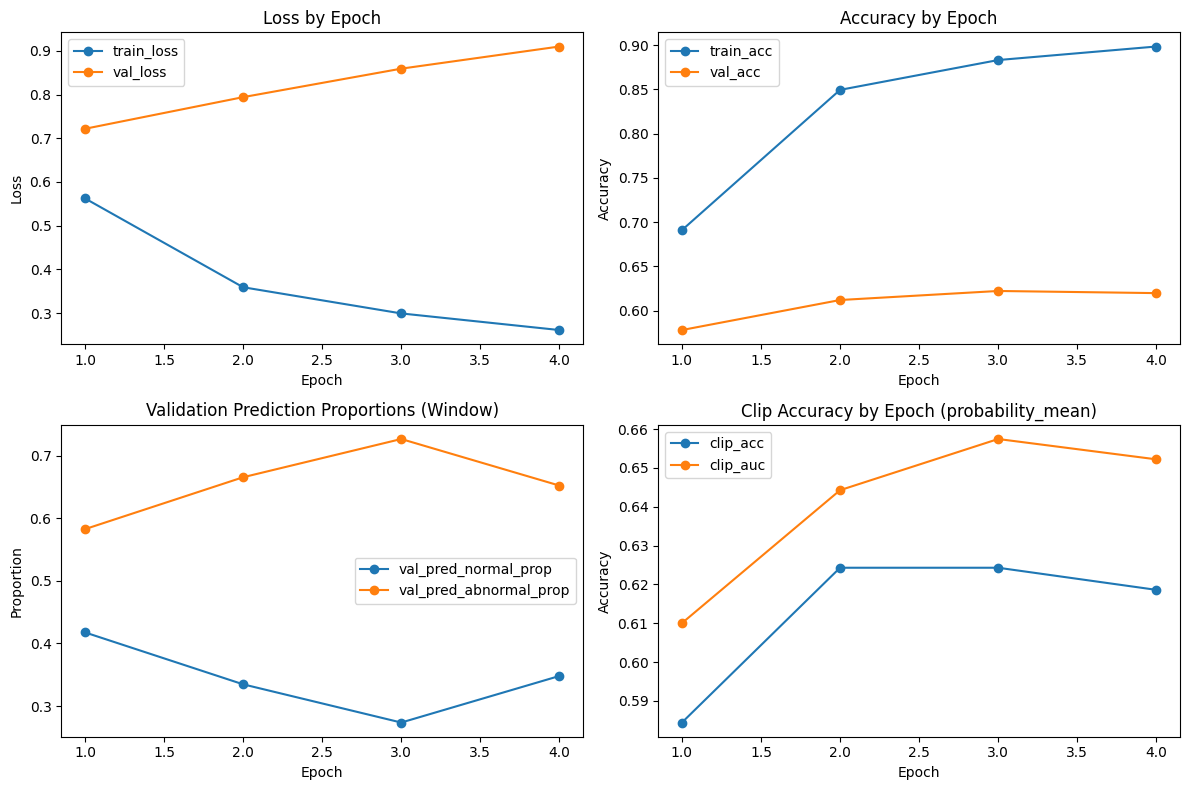

Interpretation category: B. Pipeline works, weak but nontrivial signal
normal_recall=0.4562, abnormal_recall=0.7150, val_acc=0.6198


In [30]:
def _evaluate_loader(loader, expect_clip_id: bool = False):
    model.eval()
    y_true = []
    y_pred = []
    loss_sum = 0.0
    count = 0
    window_records = []

    with torch.no_grad():
        for batch in loader:
            if expect_clip_id:
                if len(batch) != 3:
                    raise RuntimeError('Expected loader batch to be (x, y, clip_id).')
                x, y, clip_ids = batch
            else:
                if len(batch) == 2:
                    x, y = batch
                    clip_ids = None
                elif len(batch) == 3:
                    x, y, clip_ids = batch
                else:
                    raise RuntimeError(f'Unexpected batch structure (len={len(batch)}).')

            x = x.to(runtime_device, non_blocking=True)
            y = y.to(runtime_device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            preds = torch.argmax(logits, dim=1)
            probs = torch.softmax(logits, dim=1)
            abnormal_probs = probs[:, 1]

            y_cpu = y.detach().cpu().numpy().tolist()
            pred_cpu = preds.detach().cpu().numpy().tolist()

            y_true.extend(y_cpu)
            y_pred.extend(pred_cpu)
            loss_sum += float(loss.item()) * x.size(0)
            count += int(x.size(0))

            if expect_clip_id:
                clip_ids_list = [str(c) for c in clip_ids]
                abnormal_probs_cpu = abnormal_probs.detach().cpu().numpy().tolist()
                if len(clip_ids_list) != len(y_cpu):
                    raise RuntimeError(
                        f'clip_id batch size mismatch during evaluation: clip_ids={len(clip_ids_list)}, labels={len(y_cpu)}'
                    )

                for clip_id_item, true_label_item, pred_item, abnormal_prob_item in zip(
                    clip_ids_list,
                    y_cpu,
                    pred_cpu,
                    abnormal_probs_cpu,
                ):
                    clip_id_clean = str(clip_id_item).strip()
                    if not clip_id_clean or clip_id_clean.lower() == 'nan':
                        raise RuntimeError('clip_id exists check failed during evaluation.')
                    window_records.append(
                        {
                            'clip_id': clip_id_clean,
                            'true_label': int(true_label_item),
                            'pred_class': int(pred_item),
                            'abnormal_prob': float(abnormal_prob_item),
                        }
                    )

    return (
        np.asarray(y_true, dtype=np.int64),
        np.asarray(y_pred, dtype=np.int64),
        (loss_sum / max(1, count)),
        window_records,
    )


if history['epoch']:
    final_train_loss = history['train_loss'][-1]
    final_val_loss_from_epoch = history['val_loss'][-1]
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]
else:
    final_train_loss = float('nan')
    final_val_loss_from_epoch = float('nan')
    final_train_acc = float('nan')
    final_val_acc = float('nan')

val_y_true, val_y_pred, eval_val_loss, val_eval_window_records = _evaluate_loader(val_loader, expect_clip_id=True)
train_y_true, train_y_pred, eval_train_loss, _ = _evaluate_loader(train_loader, expect_clip_id=False)

cm = _confusion_matrix_binary(val_y_true, val_y_pred)
confusion_df = pd.DataFrame(
    cm,
    index=['true_normal', 'true_abnormal'],
    columns=['pred_normal', 'pred_abnormal'],
)
CHECKS['confusion matrix generated'] = True

pred_normal = int((val_y_pred == 0).sum())
pred_abnormal = int((val_y_pred == 1).sum())
pred_total = int(len(val_y_pred))
pred_normal_prop = pred_normal / pred_total if pred_total else 0.0
pred_abnormal_prop = pred_abnormal / pred_total if pred_total else 0.0
CHECKS['prediction distribution computed'] = True

clip_eval_metrics = _compute_clip_level_metrics_from_records(
    val_eval_window_records,
    aggregation_method=clip_aggregation_method,
    include_report=True,
)
clip_summary_df = clip_eval_metrics['per_clip_summary_df'].copy()
clip_cm = clip_eval_metrics['clip_confusion_matrix']
clip_confusion_df = pd.DataFrame(
    clip_cm,
    index=['true_normal', 'true_abnormal'],
    columns=['pred_normal', 'pred_abnormal'],
)
clip_count = int(clip_eval_metrics['clip_count'])
clip_accuracy = float(clip_eval_metrics['clip_accuracy'])
clip_pred_normal = int(clip_eval_metrics['clip_pred_normal'])
clip_pred_abnormal = int(clip_eval_metrics['clip_pred_abnormal'])
clip_pred_normal_prop = float(clip_eval_metrics['clip_pred_normal_prop'])
clip_pred_abnormal_prop = float(clip_eval_metrics['clip_pred_abnormal_prop'])
clip_auc = clip_eval_metrics.get('clip_auc')
clip_auc_warning = clip_eval_metrics.get('clip_auc_warning')
clip_classification_report_text = clip_eval_metrics['clip_classification_report_text']
clip_classification_report_dict = clip_eval_metrics['clip_classification_report_dict']

CHECKS['clip-level metrics computed'] = True

print('final train loss:', final_train_loss)
print('final validation loss:', final_val_loss_from_epoch)
print('final train accuracy:', final_train_acc)
print('final validation accuracy:', final_val_acc)
print('evaluation train loss:', eval_train_loss)
print('evaluation validation loss:', eval_val_loss)
print('confusion matrix:')
display(confusion_df)
print('prediction distribution on validation set:')
print(f'predicted normal={pred_normal}, predicted abnormal={pred_abnormal}')
print(f'predicted normal proportion={pred_normal_prop:.4f}, predicted abnormal proportion={pred_abnormal_prop:.4f}')

print('clip-level report (validation):')
print(f'clip_aggregation_method={clip_aggregation_method}')
print(f'clip_count={clip_count}')
print(f'clip_accuracy={clip_accuracy:.4f}')
print(f'clip_auc={_format_optional_metric(clip_auc)}')
if clip_auc_warning is not None:
    print(f'clip_auc_note={clip_auc_warning}')
print('clip_confusion_matrix:')
display(clip_confusion_df)
print(f'predicted normal clips={clip_pred_normal}, predicted abnormal clips={clip_pred_abnormal}')
print(
    f'predicted normal clip proportion={clip_pred_normal_prop:.4f}, '
    f'predicted abnormal clip proportion={clip_pred_abnormal_prop:.4f}'
)
print(
    f'clip_accuracy(probability_mean)={clip_eval_metrics["probability_mean_accuracy"]:.4f}, '
    f'clip_accuracy(majority_vote)={clip_eval_metrics["majority_vote_accuracy"]:.4f}'
)

classification_report_text = None
classification_report_dict = None
if SKLEARN_AVAILABLE:
    print('classification report (validation windows):')
    classification_report_text = classification_report(
        val_y_true,
        val_y_pred,
        labels=[0, 1],
        target_names=['normal', 'abnormal'],
        digits=4,
        zero_division=0,
    )
    print(classification_report_text)
    classification_report_dict = classification_report(
        val_y_true,
        val_y_pred,
        labels=[0, 1],
        target_names=['normal', 'abnormal'],
        output_dict=True,
        zero_division=0,
    )

    print('classification report (validation clips):')
    if clip_classification_report_text is not None:
        print(clip_classification_report_text)
else:
    print('sklearn.metrics not available; skipping classification reports.')

history_df = pd.DataFrame(history)
display(history_df.tail(min(10, len(history_df))))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(history['epoch'], history['train_loss'], marker='o', label='train_loss')
axes[0, 0].plot(history['epoch'], history['val_loss'], marker='o', label='val_loss')
axes[0, 0].set_title('Loss by Epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].plot(history['epoch'], history['train_acc'], marker='o', label='train_acc')
axes[0, 1].plot(history['epoch'], history['val_acc'], marker='o', label='val_acc')
axes[0, 1].set_title('Accuracy by Epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

axes[1, 0].plot(history['epoch'], history['val_pred_normal_prop'], marker='o', label='val_pred_normal_prop')
axes[1, 0].plot(history['epoch'], history['val_pred_abnormal_prop'], marker='o', label='val_pred_abnormal_prop')
axes[1, 0].set_title('Validation Prediction Proportions (Window)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].legend()

axes[1, 1].plot(history['epoch'], history['clip_acc'], marker='o', label='clip_acc')
if 'clip_auc' in history:
    axes[1, 1].plot(history['epoch'], history['clip_auc'], marker='o', label='clip_auc')
axes[1, 1].set_title(f'Clip Accuracy by Epoch ({clip_aggregation_method})')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

fig.tight_layout()
plt.show()
CHECKS['history plots generated'] = True

tn, fp = int(cm[0, 0]), int(cm[0, 1])
fn, tp = int(cm[1, 0]), int(cm[1, 1])

normal_recall = tn / (tn + fp) if (tn + fp) else 0.0
abnormal_recall = tp / (tp + fn) if (tp + fn) else 0.0

collapse_detected = (pred_normal == 0 or pred_abnormal == 0 or max(pred_normal_prop, pred_abnormal_prop) >= 0.95)

if collapse_detected:
    interpretation_category = 'A. Pipeline works, model still collapses'
elif final_val_acc >= 0.65 and normal_recall > 0.0 and abnormal_recall > 0.0:
    interpretation_category = 'C. Pipeline works, meaningful signal emerging'
elif final_val_acc > 0.50 and normal_recall > 0.0 and abnormal_recall > 0.0:
    interpretation_category = 'B. Pipeline works, weak but nontrivial signal'
else:
    interpretation_category = 'A. Pipeline works, model still collapses'

final_metrics = {
    'final_train_loss': float(final_train_loss),
    'final_val_loss_from_epoch': float(final_val_loss_from_epoch),
    'eval_train_loss': float(eval_train_loss),
    'eval_val_loss': float(eval_val_loss),
    'final_train_accuracy': float(final_train_acc),
    'final_val_accuracy': float(final_val_acc),
    'pred_normal_count': int(pred_normal),
    'pred_abnormal_count': int(pred_abnormal),
    'pred_normal_prop': float(pred_normal_prop),
    'pred_abnormal_prop': float(pred_abnormal_prop),
    'normal_recall': float(normal_recall),
    'abnormal_recall': float(abnormal_recall),
    'collapse_detected': bool(collapse_detected),
    'best_epoch': int(best_epoch) if best_epoch is not None else None,
    'best_val_loss': float(best_val_loss) if best_val_loss != float('inf') else None,
    'best_clip_acc': float(best_clip_acc) if best_clip_acc is not None else None,
    'best_clip_auc': float(best_clip_auc) if best_clip_auc is not None else None,
    'clip_aggregation_method': clip_aggregation_method,
    'clip_count': int(clip_count),
    'clip_accuracy': float(clip_accuracy),
    'clip_auc': float(clip_auc) if clip_auc is not None else None,
    'clip_auc_warning': clip_auc_warning,
    'clip_pred_normal_count': int(clip_pred_normal),
    'clip_pred_abnormal_count': int(clip_pred_abnormal),
    'clip_pred_normal_prop': float(clip_pred_normal_prop),
    'clip_pred_abnormal_prop': float(clip_pred_abnormal_prop),
    'clip_accuracy_probability_mean': float(clip_eval_metrics['probability_mean_accuracy']),
    'clip_accuracy_majority_vote': float(clip_eval_metrics['majority_vote_accuracy']),
}

print('Interpretation category:', interpretation_category)
print(f'normal_recall={normal_recall:.4f}, abnormal_recall={abnormal_recall:.4f}, val_acc={final_val_acc:.4f}')


## 7. Artifact writeout


In [31]:
def _run_git_command(args):
    try:
        result = subprocess.run(
            ['git', *args],
            cwd=REPO_ROOT,
            check=False,
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            return None
        return result.stdout.strip()
    except Exception:
        return None


def _git_info():
    status_short = _run_git_command(['status', '--short'])
    return {
        'git_commit': _run_git_command(['rev-parse', 'HEAD']),
        'git_branch': _run_git_command(['rev-parse', '--abbrev-ref', 'HEAD']),
        'dirty_worktree': bool(status_short),
        'git_status_short': status_short.splitlines() if status_short else [],
    }


run_timestamp = datetime.now().strftime('%Y%m%d-%H%M')
run_notebook_stem = NOTEBOOK_RELATIVE_PATH.stem
MODEL_OUTPUT_DIR = models_root / f'{run_timestamp}-{run_notebook_stem}'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = MODEL_OUTPUT_DIR / 'final_model_state_dict.pt'
BEST_MODEL_PATH = MODEL_OUTPUT_DIR / 'best_val_model_state_dict.pt'
TRAINING_HISTORY_JSON_PATH = MODEL_OUTPUT_DIR / 'training_history.json'
METRICS_JSON_PATH = MODEL_OUTPUT_DIR / 'metrics.json'
RUN_MANIFEST_JSON_PATH = MODEL_OUTPUT_DIR / 'run_manifest.json'
SPLIT_MEMBERSHIP_PATH = MODEL_OUTPUT_DIR / 'split_membership.csv'
CLIP_LEVEL_SUMMARY_CSV_PATH = MODEL_OUTPUT_DIR / 'clip_level_predictions.csv'
CLIP_LEVEL_SUMMARY_JSON_PATH = MODEL_OUTPUT_DIR / 'clip_level_predictions.json'
MODEL_CARD_PATH = MODEL_OUTPUT_DIR / 'model_card.md'

local_artifacts = {}
if save_local_checkpoints:
    final_checkpoint = {
        'model_state_dict': model.state_dict(),
        'input_mode': input_mode,
        'manifest_mode': manifest_mode,
        'epoch_count_ran': len(history['epoch']),
        'random_seed': random_seed,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'device': str(runtime_device),
    }
    torch.save(final_checkpoint, FINAL_MODEL_PATH)

    if best_state_dict is None:
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = history['epoch'][-1] if history['epoch'] else None

    best_checkpoint = {
        'model_state_dict': best_state_dict,
        'best_val_loss': float(best_val_loss) if best_val_loss != float('inf') else None,
        'best_epoch': int(best_epoch) if best_epoch is not None else None,
        'best_clip_acc': float(best_clip_acc) if best_clip_acc is not None else None,
        'best_clip_auc': float(best_clip_auc) if best_clip_auc is not None else None,
        'best_clip_metrics': best_clip_metrics,
        'input_mode': input_mode,
        'random_seed': random_seed,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'device': str(runtime_device),
    }
    torch.save(best_checkpoint, BEST_MODEL_PATH)

    local_artifacts = {
        'final_checkpoint_local_only': repo_rel(FINAL_MODEL_PATH),
        'best_val_checkpoint_local_only': repo_rel(BEST_MODEL_PATH),
    }

split_membership_df.to_csv(SPLIT_MEMBERSHIP_PATH, index=False)
CHECKS['split membership saved'] = True

clip_summary_df.to_csv(CLIP_LEVEL_SUMMARY_CSV_PATH, index=False)
clip_summary_records = json.loads(clip_summary_df.to_json(orient='records'))
CLIP_LEVEL_SUMMARY_JSON_PATH.write_text(json.dumps(clip_summary_records, indent=2))
CHECKS['clip-level artifacts saved'] = True

metrics_payload = {
    'run_id': MODEL_OUTPUT_DIR.name,
    'notebook': repo_rel(NOTEBOOK_PATH),
    'input_mode': input_mode,
    'machine_filter': machine_filter,
    'final_metrics': final_metrics,
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report_dict,
    'clip_aggregation_method': clip_aggregation_method,
    'clip_confusion_matrix': clip_cm.tolist(),
    'clip_classification_report': clip_classification_report_dict,
    'clip_summary_csv_path': repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH),
    'clip_summary_json_path': repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH),
    'interpretation_category': interpretation_category,
}
METRICS_JSON_PATH.write_text(json.dumps(metrics_payload, indent=2))
CHECKS['metrics artifact saved'] = True

history_payload = {
    'run_id': MODEL_OUTPUT_DIR.name,
    'notebook': repo_rel(NOTEBOOK_PATH),
    'input_mode': input_mode,
    'machine_filter': machine_filter,
    'random_seed': random_seed,
    'window_manifest_paths': [repo_rel(p) for p in window_manifest_paths],
    'clip_manifest_paths': [repo_rel(p) for p in clip_manifest_paths],
    'preprocessing_config_paths': [repo_rel(p) for p in preprocessing_config_paths],
    'hyperparameters': {
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'learning_rate': learning_rate,
        'device': str(runtime_device),
        'val_fraction': val_fraction,
        'deterministic_training': deterministic_training,
        'clip_aggregation_method': clip_aggregation_method,
        'split_strategy': split_strategy,
        'unit_holdout_ids_config': unit_holdout_ids,
        'auto_select_holdout_units': bool(auto_select_holdout_units),
        'num_holdout_units': int(num_holdout_units),
        'require_balanced_unit_holdout': bool(require_balanced_unit_holdout),
        'resolved_holdout_unit_ids': resolved_holdout_unit_ids,
    },
    'subset_summary': {
        'selected_normal_clips': int(len(selected_normal_df)),
        'selected_abnormal_clips': int(len(selected_abnormal_df)),
        'train_normal_clips': int(train_normal_clips),
        'train_abnormal_clips': int(train_abnormal_clips),
        'val_normal_clips': int(val_normal_clips),
        'val_abnormal_clips': int(val_abnormal_clips),
        'train_normal_windows': int(train_normal_windows),
        'train_abnormal_windows': int(train_abnormal_windows),
        'val_normal_windows': int(val_normal_windows),
        'val_abnormal_windows': int(val_abnormal_windows),
        'selected_unit_ids': selected_unit_ids,
        'train_unit_ids': train_unit_ids,
        'val_unit_ids': val_unit_ids,
    },
    'split_artifact_path': repo_rel(SPLIT_MEMBERSHIP_PATH),
    'history': history,
    'final_metrics': final_metrics,
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report_dict,
    'clip_confusion_matrix': clip_cm.tolist(),
    'clip_classification_report': clip_classification_report_dict,
    'clip_summary_csv_path': repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH),
    'clip_summary_json_path': repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH),
    'interpretation_category': interpretation_category,
    'checklist': CHECKS,
}
TRAINING_HISTORY_JSON_PATH.write_text(json.dumps(history_payload, indent=2))

git_info = _git_info()
environment_summary = {
    'python_version': platform.python_version(),
    'torch_version': getattr(torch, '__version__', None),
    'torchaudio_version': getattr(torchaudio, '__version__', None) if torchaudio is not None else None,
    'numpy_version': getattr(np, '__version__', None),
    'pandas_version': getattr(pd, '__version__', None),
    'pyarrow_version': getattr(pyarrow, '__version__', None) if pyarrow is not None else None,
    'cuda_version': getattr(torch.version, 'cuda', None),
    'device': str(runtime_device),
    'deterministic_training': bool(deterministic_training),
    'requirements_path': repo_rel(REPO_ROOT / 'requirements.txt'),
    'requirements_sha256': sha256_file(REPO_ROOT / 'requirements.txt'),
}

source_manifest_paths = [*window_manifest_paths, *clip_manifest_paths]
source_manifest_sha256 = {repo_rel(p): sha256_file(p) for p in source_manifest_paths}
preprocessing_config_sha256 = {repo_rel(p): sha256_file(p) for p in preprocessing_config_paths}

run_manifest = {
    'run_id': MODEL_OUTPUT_DIR.name,
    'created_utc': utc_now_iso(),
    'git_commit': git_info['git_commit'],
    'git_branch': git_info['git_branch'],
    'dirty_worktree': git_info['dirty_worktree'],
    'git_status_short': git_info['git_status_short'],
    'entrypoint_type': 'notebook',
    'entrypoint_path': repo_rel(NOTEBOOK_PATH),
    'entrypoint_sha256': sha256_file(NOTEBOOK_PATH),
    'manifest_mode': manifest_mode,
    'source_manifest_paths': [repo_rel(p) for p in source_manifest_paths],
    'source_manifest_sha256': source_manifest_sha256,
    'window_manifest_paths': [repo_rel(p) for p in window_manifest_paths],
    'clip_manifest_paths': [repo_rel(p) for p in clip_manifest_paths],
    'preprocessing_config_paths': [repo_rel(p) for p in preprocessing_config_paths],
    'preprocessing_config_sha256': preprocessing_config_sha256,
    'dataset_summary': {
        'machine_filter': machine_filter,
        'selected_normal_clips': int(len(selected_normal_df)),
        'selected_abnormal_clips': int(len(selected_abnormal_df)),
        'train_clip_ids': sorted([str(x) for x in train_clip_ids]),
        'val_clip_ids': sorted([str(x) for x in val_clip_ids]),
        'split_artifact_path': repo_rel(SPLIT_MEMBERSHIP_PATH),
        'split_strategy': split_strategy,
        'resolved_holdout_unit_ids': resolved_holdout_unit_ids,
        'selected_unit_ids': selected_unit_ids,
        'train_unit_ids': train_unit_ids,
        'val_unit_ids': val_unit_ids,
    },
    'model_name': 'Baseline2DCNN',
    'model_architecture_summary': (
        'Conv2d(2->16,k5)+ReLU+MaxPool -> Conv2d(16->32,k3)+ReLU+MaxPool -> '
        'Conv2d(32->64,k3)+ReLU+MaxPool -> AdaptiveAvgPool2d(1,1) -> Linear(64->2)'
    ),
    'input_representation': input_mode,
    'input_shape': [2, 96, 64],
    'optimizer': 'Adam',
    'loss_function': 'CrossEntropyLoss',
    'hyperparameters': {
        'batch_size': batch_size,
        'num_epochs_config': num_epochs,
        'learning_rate': learning_rate,
        'val_fraction': val_fraction,
        'match_normal_to_abnormal_when_abnormal_limited': match_normal_to_abnormal_when_abnormal_limited,
        'clip_aggregation_method': clip_aggregation_method,
        'split_strategy': split_strategy,
        'unit_holdout_ids_config': unit_holdout_ids,
        'auto_select_holdout_units': bool(auto_select_holdout_units),
        'num_holdout_units': int(num_holdout_units),
        'require_balanced_unit_holdout': bool(require_balanced_unit_holdout),
        'resolved_holdout_unit_ids': resolved_holdout_unit_ids,
    },
    'random_seeds': {
        'python_random': random_seed,
        'numpy': random_seed,
        'torch': random_seed,
        'torch_cuda_manual_seed_all': random_seed if torch.cuda.is_available() else None,
    },
    'environment': environment_summary,
    'artifact_paths': {
        'training_history': repo_rel(TRAINING_HISTORY_JSON_PATH),
        'metrics': repo_rel(METRICS_JSON_PATH),
        'split_membership': repo_rel(SPLIT_MEMBERSHIP_PATH),
        'clip_level_summary_csv': repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH),
        'clip_level_summary_json': repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH),
        'model_card': repo_rel(MODEL_CARD_PATH),
        **local_artifacts,
    },
    'change_note': change_note,
}
RUN_MANIFEST_JSON_PATH.write_text(json.dumps(run_manifest, indent=2))
CHECKS['run manifest saved'] = True

model_card = f"""# Model Card (Brief)

## Notebook
- Category: `training`
- Source notebook: `{repo_rel(NOTEBOOK_PATH)}`
- Notebook SHA256: `{sha256_file(NOTEBOOK_PATH)}`

## Model
- Name: `Baseline2DCNN`
- Architecture: Conv2d(2->16, k5) + ReLU + MaxPool, Conv2d(16->32, k3) + ReLU + MaxPool, Conv2d(32->64, k3) + ReLU + MaxPool, AdaptiveAvgPool2d(1,1), Linear(64->2)

## Task
- Binary machine-sound classification on pump clips
- Labels: `normal=0`, `abnormal=1`

## Inputs
- Window manifests: `{', '.join(repo_rel(p) for p in window_manifest_paths)}`
- Clip manifests: `{', '.join(repo_rel(p) for p in clip_manifest_paths) if clip_manifest_paths else '(derived from window manifests)'}`
- Preprocessing configs: `{', '.join(repo_rel(p) for p in preprocessing_config_paths)}`
- Base representation: `normalized_window` shape `(96, 64)` and `active_mask` shape `(96, 64)`
- Input mode: `{input_mode}`
- Final tensor shape: `(2, 96, 64)`
- Clip-level split only (no window-level random split)

## Data & Split
- Selected clips: normal={len(selected_normal_df)}, abnormal={len(selected_abnormal_df)}
- Train clips: normal={train_normal_clips}, abnormal={train_abnormal_clips}
- Validation clips: normal={val_normal_clips}, abnormal={val_abnormal_clips}
- Train windows: normal={train_normal_windows}, abnormal={train_abnormal_windows}
- Validation windows: normal={val_normal_windows}, abnormal={val_abnormal_windows}
- Exact split membership: `{repo_rel(SPLIT_MEMBERSHIP_PATH)}`
- Split strategy: `{split_strategy}`
- Holdout units (resolved): `{resolved_holdout_unit_ids}`
- Train unit ids: `{train_unit_ids}`
- Validation unit ids: `{val_unit_ids}`

## Training
- Epochs configured: {num_epochs}
- Epochs completed: {len(history['epoch'])}
- Batch size: {batch_size}
- Learning rate: {learning_rate}
- Device: {runtime_device}
- Random seed: {random_seed}
- Deterministic training flag: {deterministic_training}

## Results (This Run)
- Final train accuracy: {final_train_acc:.4f}
- Final validation accuracy (window): {final_val_acc:.4f}
- Final validation loss: {final_val_loss_from_epoch:.4f}
- Predicted distribution (window val): normal={pred_normal} ({pred_normal_prop:.4f}), abnormal={pred_abnormal} ({pred_abnormal_prop:.4f})
- Clip aggregation method: {clip_aggregation_method}
- Clip validation accuracy: {clip_accuracy:.4f}
- Clip validation ROC AUC (mean abnormal prob): {_format_optional_metric(clip_auc)}
- Predicted distribution (clip val): normal={clip_pred_normal} ({clip_pred_normal_prop:.4f}), abnormal={clip_pred_abnormal} ({clip_pred_abnormal_prop:.4f})
- Interpretation: {interpretation_category}
- Metrics JSON: `{repo_rel(METRICS_JSON_PATH)}`
- Run manifest: `{repo_rel(RUN_MANIFEST_JSON_PATH)}`

## Artifact Tracking
- Git-tracked artifacts:
  - `{repo_rel(TRAINING_HISTORY_JSON_PATH)}`
  - `{repo_rel(METRICS_JSON_PATH)}`
  - `{repo_rel(SPLIT_MEMBERSHIP_PATH)}`
  - `{repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH)}`
  - `{repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH)}`
  - `{repo_rel(RUN_MANIFEST_JSON_PATH)}`
  - `{repo_rel(MODEL_CARD_PATH)}`
- Local-only artifacts intentionally excluded from Git by `.gitignore`:
  - `{repo_rel(FINAL_MODEL_PATH) if save_local_checkpoints else 'not written'}`
  - `{repo_rel(BEST_MODEL_PATH) if save_local_checkpoints else 'not written'}`
"""
MODEL_CARD_PATH.write_text(model_card)
CHECKS['model artifacts saved'] = True

print('Saved tracked artifacts to:', repo_rel(MODEL_OUTPUT_DIR))
print(' -', repo_rel(TRAINING_HISTORY_JSON_PATH))
print(' -', repo_rel(METRICS_JSON_PATH))
print(' -', repo_rel(SPLIT_MEMBERSHIP_PATH))
print(' -', repo_rel(CLIP_LEVEL_SUMMARY_CSV_PATH))
print(' -', repo_rel(CLIP_LEVEL_SUMMARY_JSON_PATH))
print(' -', repo_rel(RUN_MANIFEST_JSON_PATH))
print(' -', repo_rel(MODEL_CARD_PATH))
if save_local_checkpoints:
    print('Local-only checkpoints:')
    print(' -', repo_rel(FINAL_MODEL_PATH))
    print(' -', repo_rel(BEST_MODEL_PATH))


Saved tracked artifacts to: models/20260323-1659-2d_sound_v0.8
 - models/20260323-1659-2d_sound_v0.8/training_history.json
 - models/20260323-1659-2d_sound_v0.8/metrics.json
 - models/20260323-1659-2d_sound_v0.8/split_membership.csv
 - models/20260323-1659-2d_sound_v0.8/clip_level_predictions.csv
 - models/20260323-1659-2d_sound_v0.8/clip_level_predictions.json
 - models/20260323-1659-2d_sound_v0.8/run_manifest.json
 - models/20260323-1659-2d_sound_v0.8/model_card.md
Local-only checkpoints:
 - models/20260323-1659-2d_sound_v0.8/final_model_state_dict.pt
 - models/20260323-1659-2d_sound_v0.8/best_val_model_state_dict.pt


## 8. Final verdict


In [32]:
print('PASS / READY')
pass_items = [k for k, v in CHECKS.items() if v]
if pass_items:
    for item in pass_items:
        print(f'- {item}')
else:
    print('- none')

print('')
print('FAIL / PATCH REQUIRED')
fail_items = [k for k, v in CHECKS.items() if not v]
if fail_items:
    for item in fail_items:
        print(f'- {item}')
else:
    print('- none')

if NAN_DETECTED:
    print('- NaN detected during training/evaluation')
if TRAINING_EXCEPTION is not None:
    print(f'- training_exception: {type(TRAINING_EXCEPTION).__name__}: {TRAINING_EXCEPTION}')

final_machine_verdict = 'READY_FOR_NEXT_DECISION' if (not fail_items and not NAN_DETECTED and TRAINING_EXCEPTION is None) else 'PATCH_REQUIRED'
print('')
print('FINAL_VERDICT:', final_machine_verdict)
print(final_machine_verdict)


PASS / READY
- manifests loaded
- clip-level split applied
- split diagnostics printed
- dataset loader works
- training completed
- prediction distribution computed
- confusion matrix generated
- clip-level metrics computed
- history plots generated
- split membership saved
- metrics artifact saved
- clip-level artifacts saved
- run manifest saved
- model artifacts saved

FAIL / PATCH REQUIRED
- none

FINAL_VERDICT: READY_FOR_NEXT_DECISION
READY_FOR_NEXT_DECISION
